<a href="https://www.kaggle.com/code/lalit7881/ncrb-crime-data-2014-eda-74-80?scriptVersionId=351051146" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arjunsinghgangwar/ncrb-crime-data-2014/All_State_NCRB_Crime_Data_2014.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/arjunsinghgangwar/ncrb-crime-data-2014/All_State_NCRB_Crime_Data_2014.csv")

In [3]:
df.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


In [4]:
df.tail()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
833,Lakshadweep,Lakshadweep,2014,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,30,81
834,Lakshadweep,Total,2014,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,30,81
835,Puducherry,Karaikal,2014,6,1,0,0,3,0,0,...,2,2,0,0,1,199,0,0,322,671
836,Puducherry,Puducherry,2014,19,14,3,0,7,1,0,...,2,2,0,9,0,974,0,0,1014,2913
837,Puducherry,Total,2014,25,15,3,0,10,1,0,...,4,4,0,9,1,1173,0,0,1336,3584


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 91 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   States/UTs                                                        838 non-null    object
 1   District                                                          838 non-null    object
 2   Year                                                              838 non-null    int64 
 3   Murder                                                            838 non-null    int64 
 4   Attempt to commit Murder                                          838 non-null    int64 
 5   Culpable Homicide not amounting to Murder                         838 non-null    int64 
 6   Attempt to commit Culpable Homicide                               838 non-null    int64 
 7   Rape                                        

In [6]:
df.describe()

,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,Custodial_Other Rape,Rape other than Custodial,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
count,838.0,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,...,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000,838.000000
mean,2014.0,81.465394,99.995227,7.992840,10.431981,92.310263,0.474940,0.016706,0.458234,91.835322,...,0.804296,0.773270,0.031026,19.594272,0.322196,978.178998,1.732697,2.739857,2253.233890,6823.243437
std,0.0,302.341738,419.969968,52.272628,71.473497,342.630462,6.756472,0.223383,6.583354,340.440065,...,3.978122,3.828292,0.307597,79.616510,6.396217,4989.771066,9.237483,12.676722,8430.873504,24094.386057
min,2014.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014.0,16.000000,11.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,31.250000,0.000000,0.000000,216.000000,947.250000
50%,2014.0,34.500000,31.000000,2.000000,0.000000,35.000000,0.000000,0.000000,0.000000,35.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,186.000000,0.000000,0.000000,791.500000,2571.500000
75%,2014.0,62.750000,65.000000,5.000000,0.000000,70.000000,0.000000,0.000000,0.000000,70.000000,...,0.000000,0.000000,0.000000,12.000000,0.000000,566.500000,0.000000,2.000000,1796.000000,4772.000000
max,2014.0,5150.000000,7355.000000,1412.000000,1433.000000,5076.000000,189.000000,5.000000,184.000000,5076.000000,...,65.000000,59.000000,6.000000,1226.000000,131.000000,108962.000000,150.000000,194.000000,127869.000000,272423.000000


In [7]:
df.isnull().sum()

States/UTs                     0
District                       0
Year                           0
Murder                         0
Attempt to commit Murder       0
                              ..
Incidence of Rash Driving      0
HumanTrafficking               0
Unnatural Offence              0
Other IPC crimes               0
Total Cognizable IPC crimes    0
Length: 91, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

States/UTs                     object
District                       object
Year                            int64
Murder                          int64
Attempt to commit Murder        int64
                                ...  
Incidence of Rash Driving       int64
HumanTrafficking                int64
Unnatural Offence               int64
Other IPC crimes                int64
Total Cognizable IPC crimes     int64
Length: 91, dtype: object

In [10]:
df.shape

(838, 91)

In [11]:
df.columns

Index(['States/UTs', 'District', 'Year', 'Murder', 'Attempt to commit Murder',
       'Culpable Homicide not amounting to Murder',
       'Attempt to commit Culpable Homicide', 'Rape', 'Custodial Rape',
       'Custodial_Gang Rape', 'Custodial_Other Rape',
       'Rape other than Custodial', 'Rape_Gang Rape', 'Rape_Others',
       'Attempt to commit Rape', 'Kidnapping & Abduction_Total',
       'Kidnapping & Abduction', 'Kidnapping & Abduction in order to Murder',
       'Kidnapping for Ransom',
       'Kidnapping & Abduction of Women to compel her for marriage',
       'Other Kidnapping', 'Dacoity', 'Dacoity with Murder', 'Other Dacoity',
       'Making Preparation and Assembly for committing Dacoity', 'Robbery',
       'Criminal Trespass/Burglary', 'Criminal Trespass or Burglary',
       'House Trespass & House Breaking', 'Theft', 'Auto Theft',
       'Other Thefts', 'Unlawful Assembly', 'Riots', 'Riots_Communal',
       'Riots_Industrial', 'Riots_Political', 'Riots_Caste Conflict',


In [12]:
df.nunique()

States/UTs                      36
District                       783
Year                             1
Murder                         164
Attempt to commit Murder       191
                              ... 
Incidence of Rash Driving      496
HumanTrafficking                33
Unnatural Offence               35
Other IPC crimes               690
Total Cognizable IPC crimes    783
Length: 91, dtype: int64

## EDA

DATASET SHAPE
Rows   : 838
Columns: 91

DATA TYPES
States/UTs                     object
District                       object
Year                            int64
Murder                          int64
Attempt to commit Murder        int64
                                ...  
Incidence of Rash Driving       int64
HumanTrafficking                int64
Unnatural Offence               int64
Other IPC crimes                int64
Total Cognizable IPC crimes     int64
Length: 91, dtype: object

MISSING VALUES
States/UTs                                                    0
District                                                      0
Year                                                          0
Murder                                                        0
Attempt to commit Murder                                      0
Culpable Homicide not amounting to Murder                     0
Attempt to commit Culpable Homicide                           0
Rape                                     

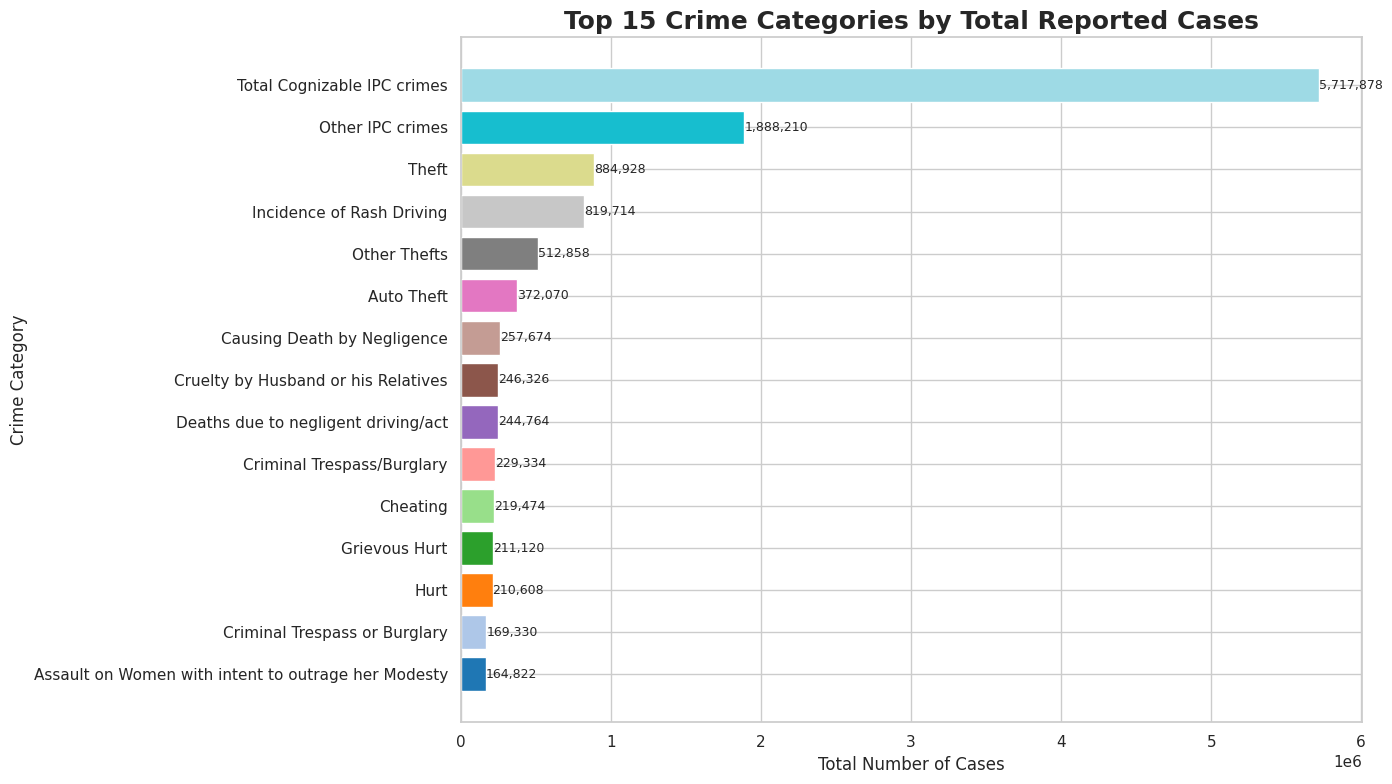

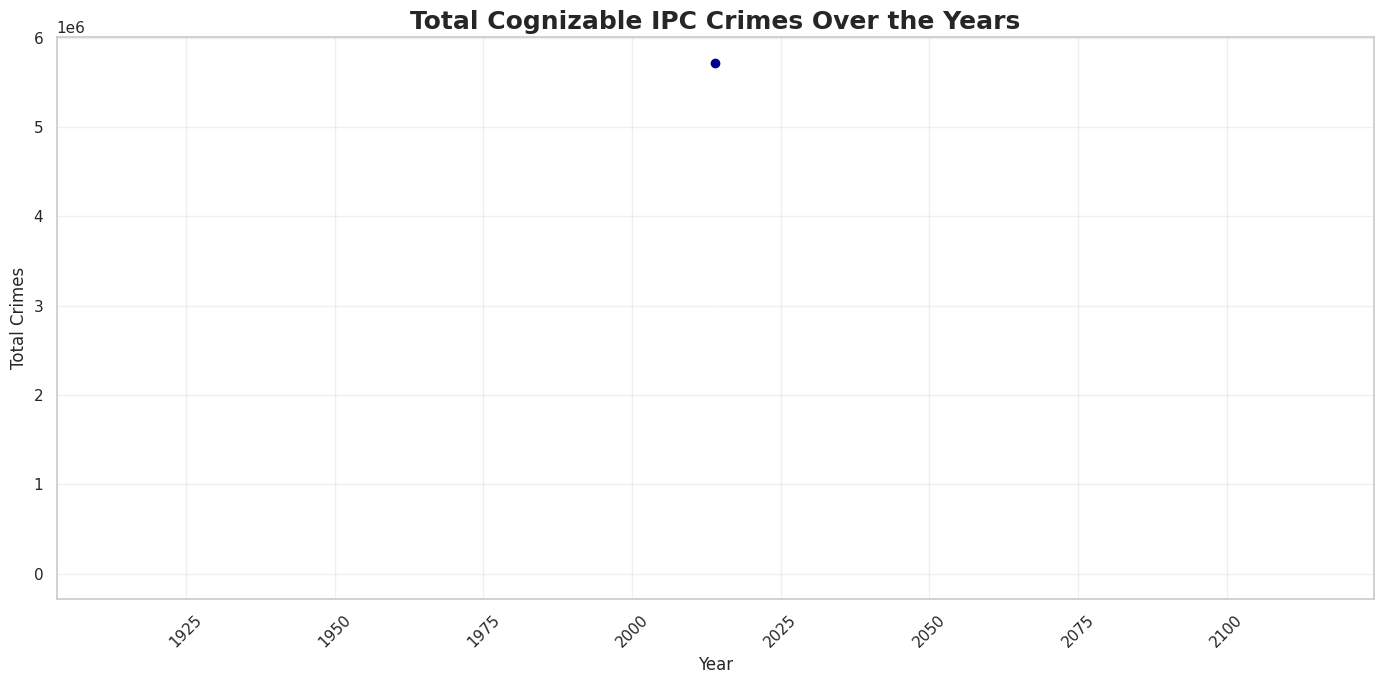

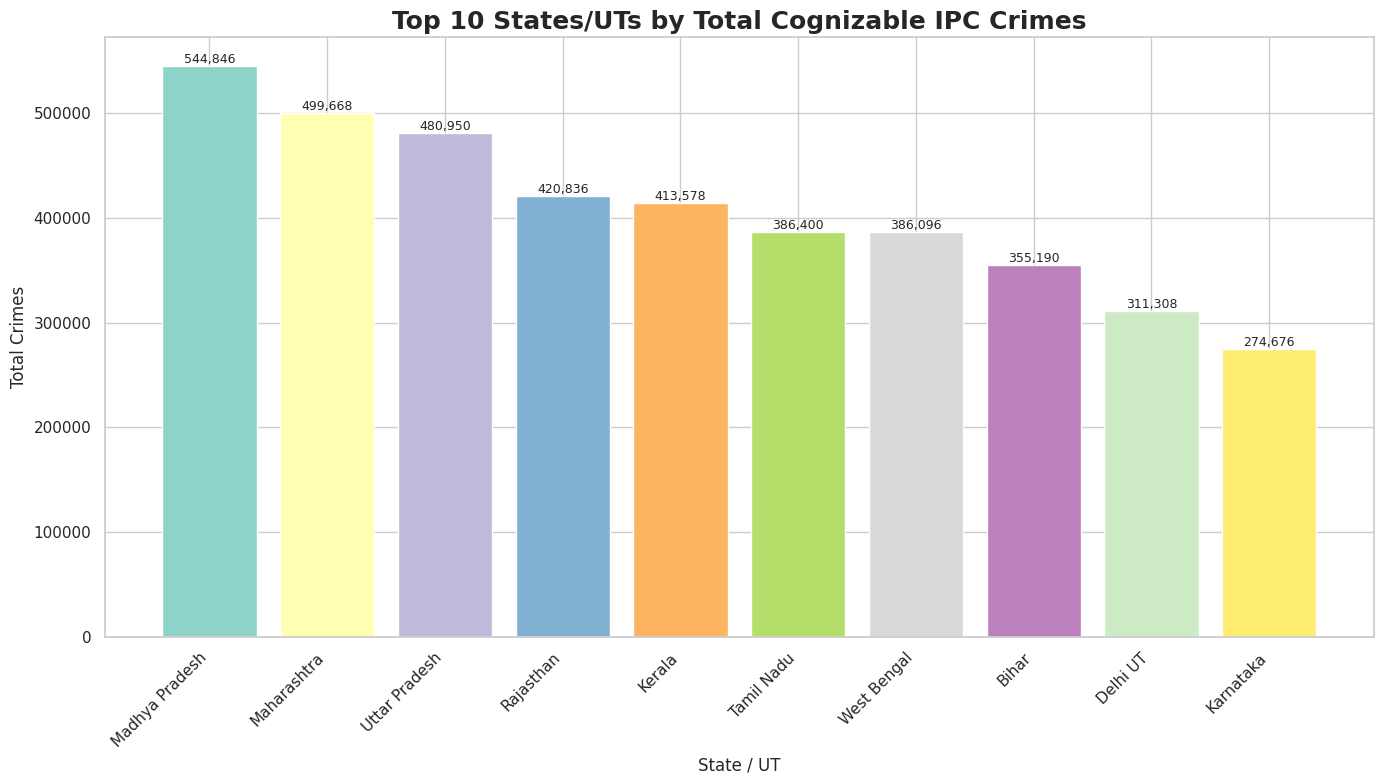

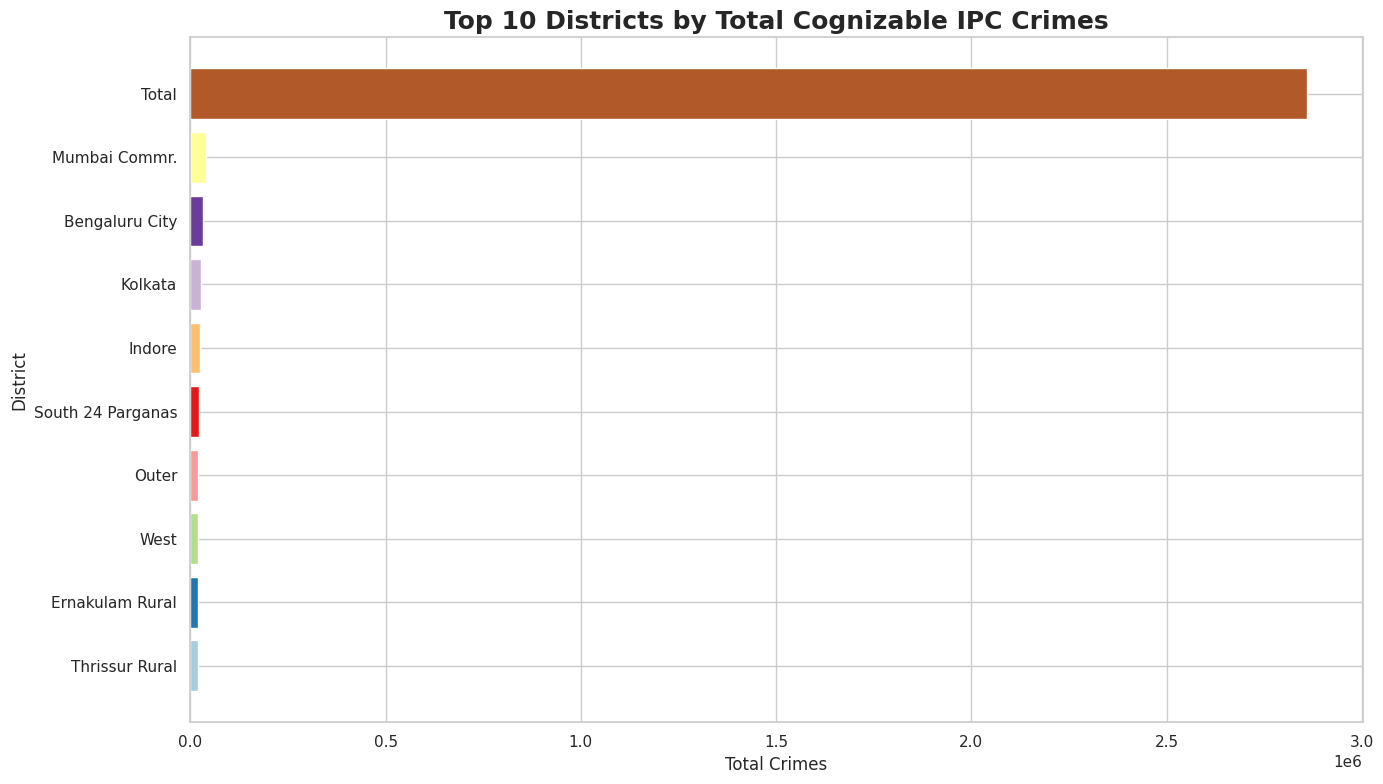

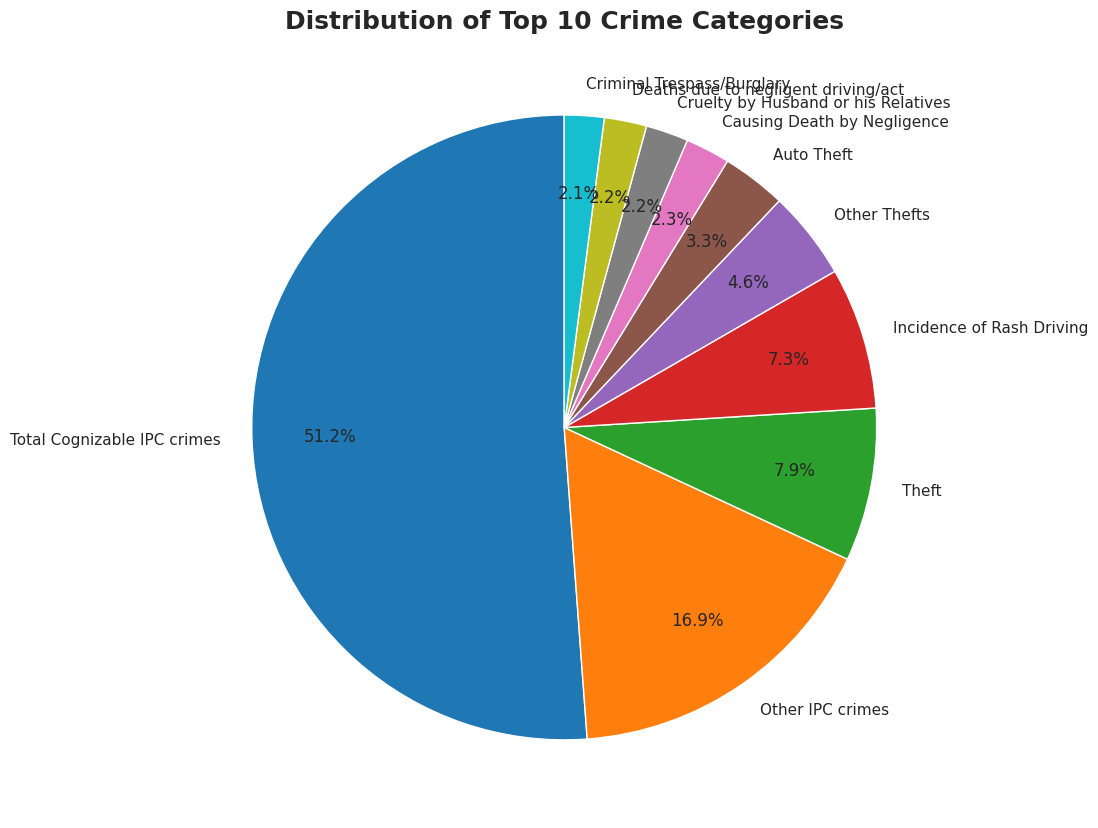

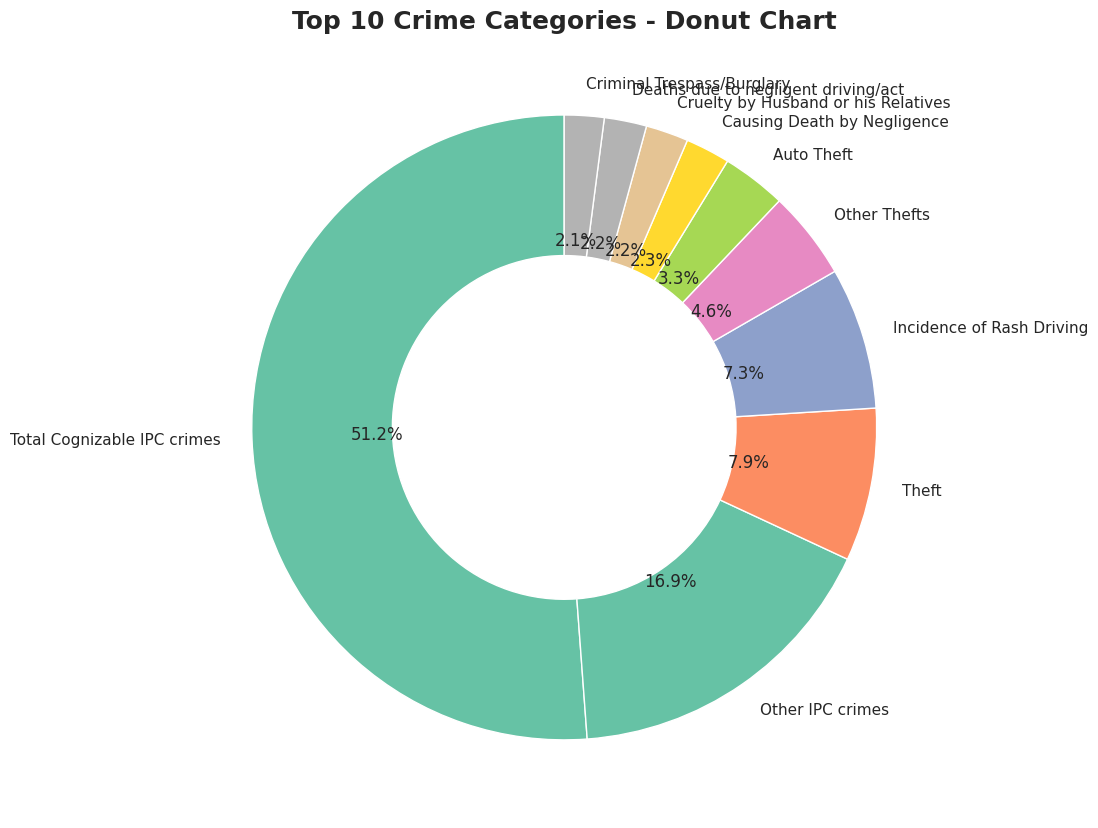

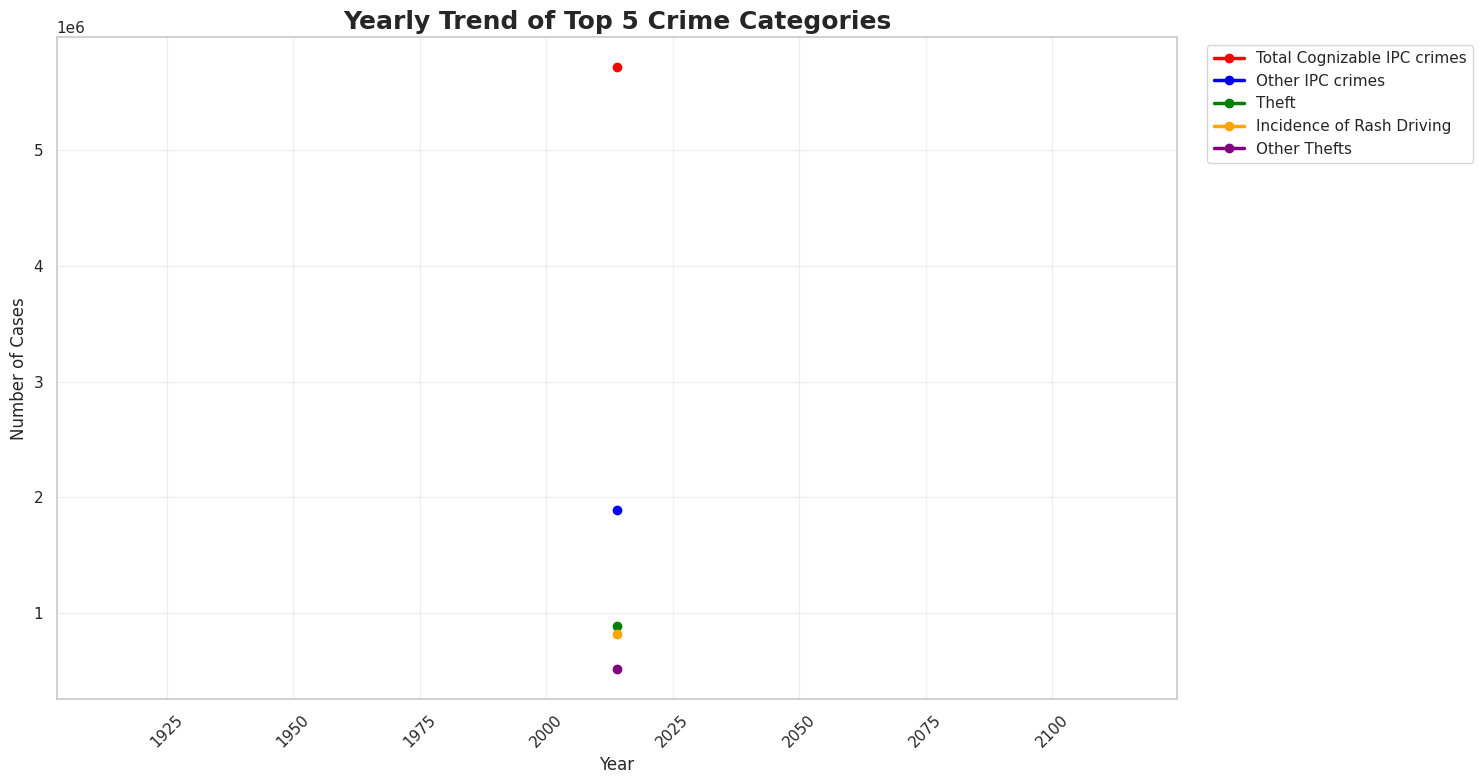

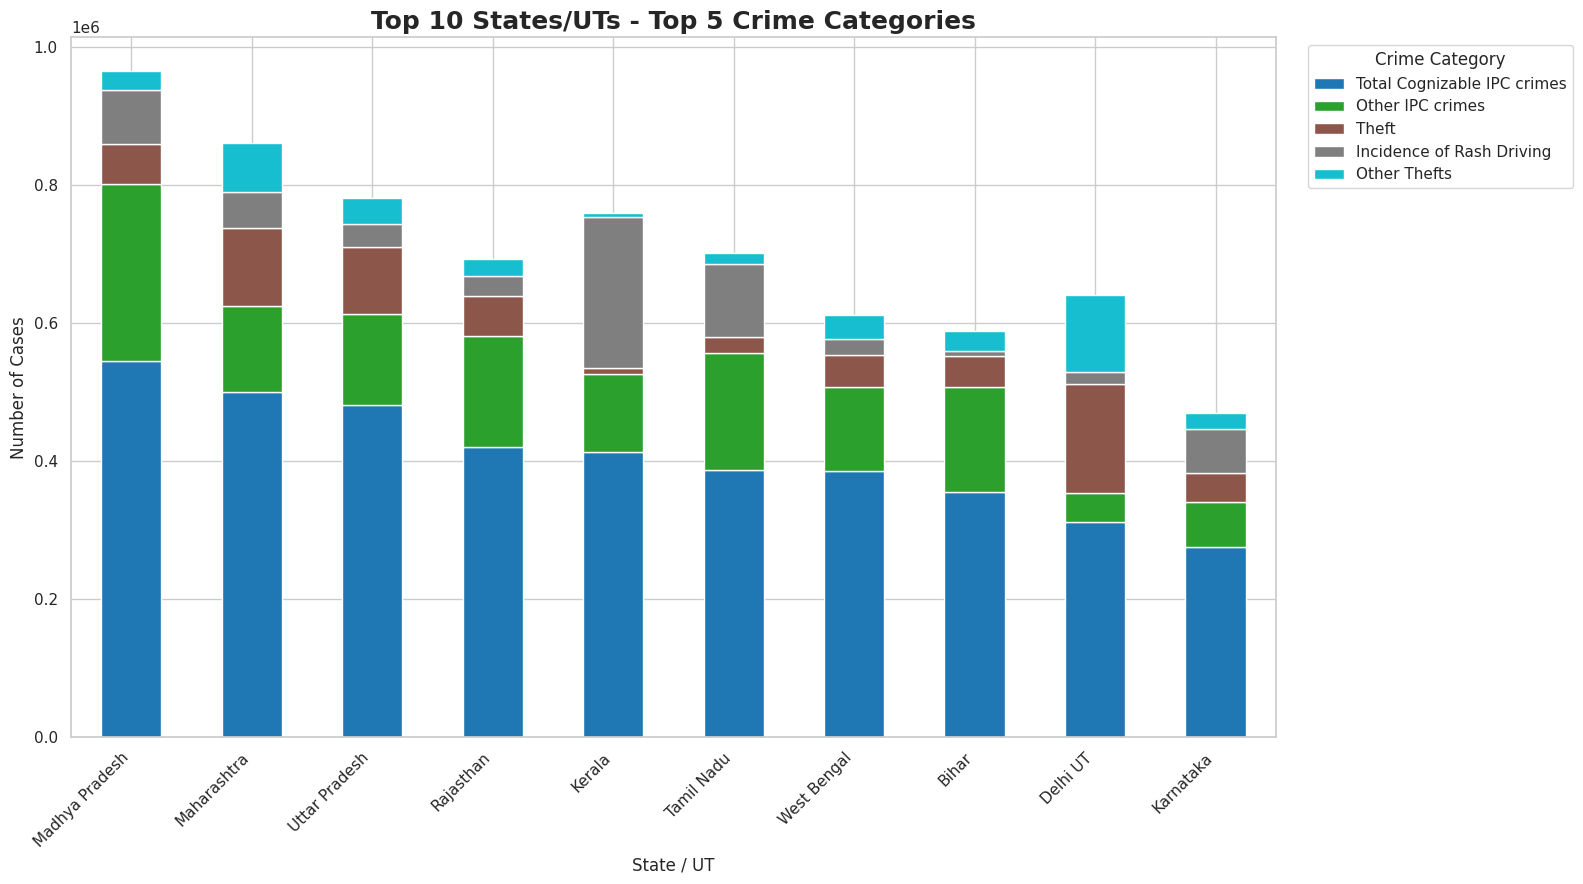

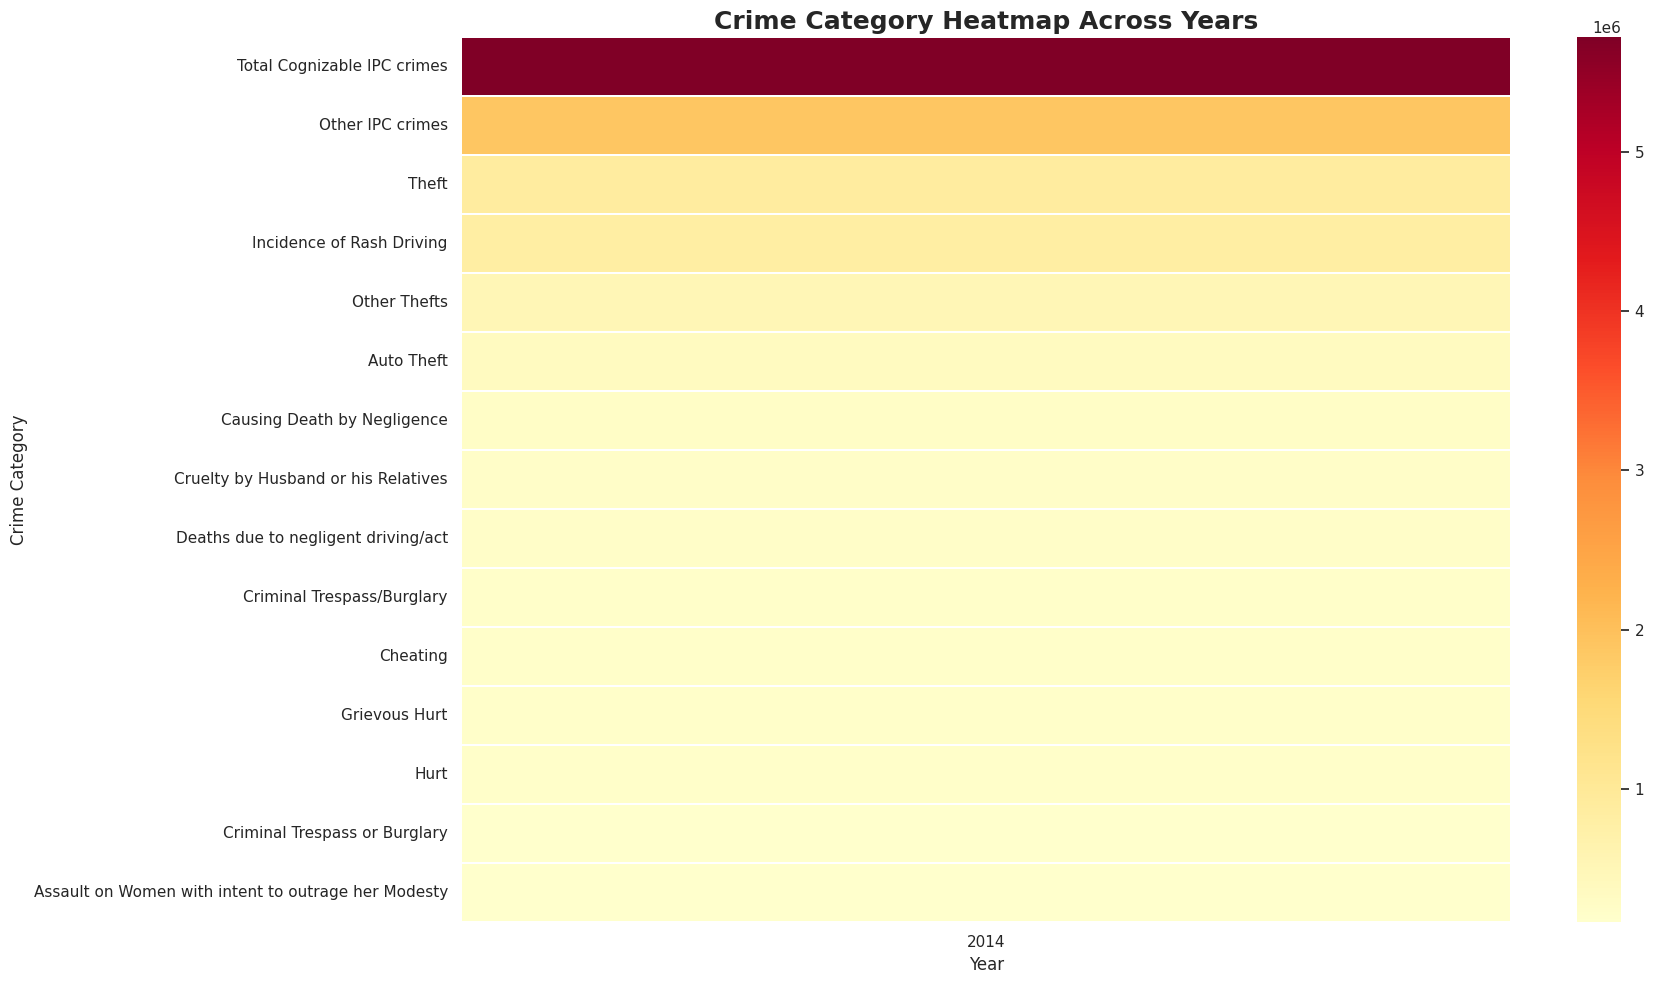

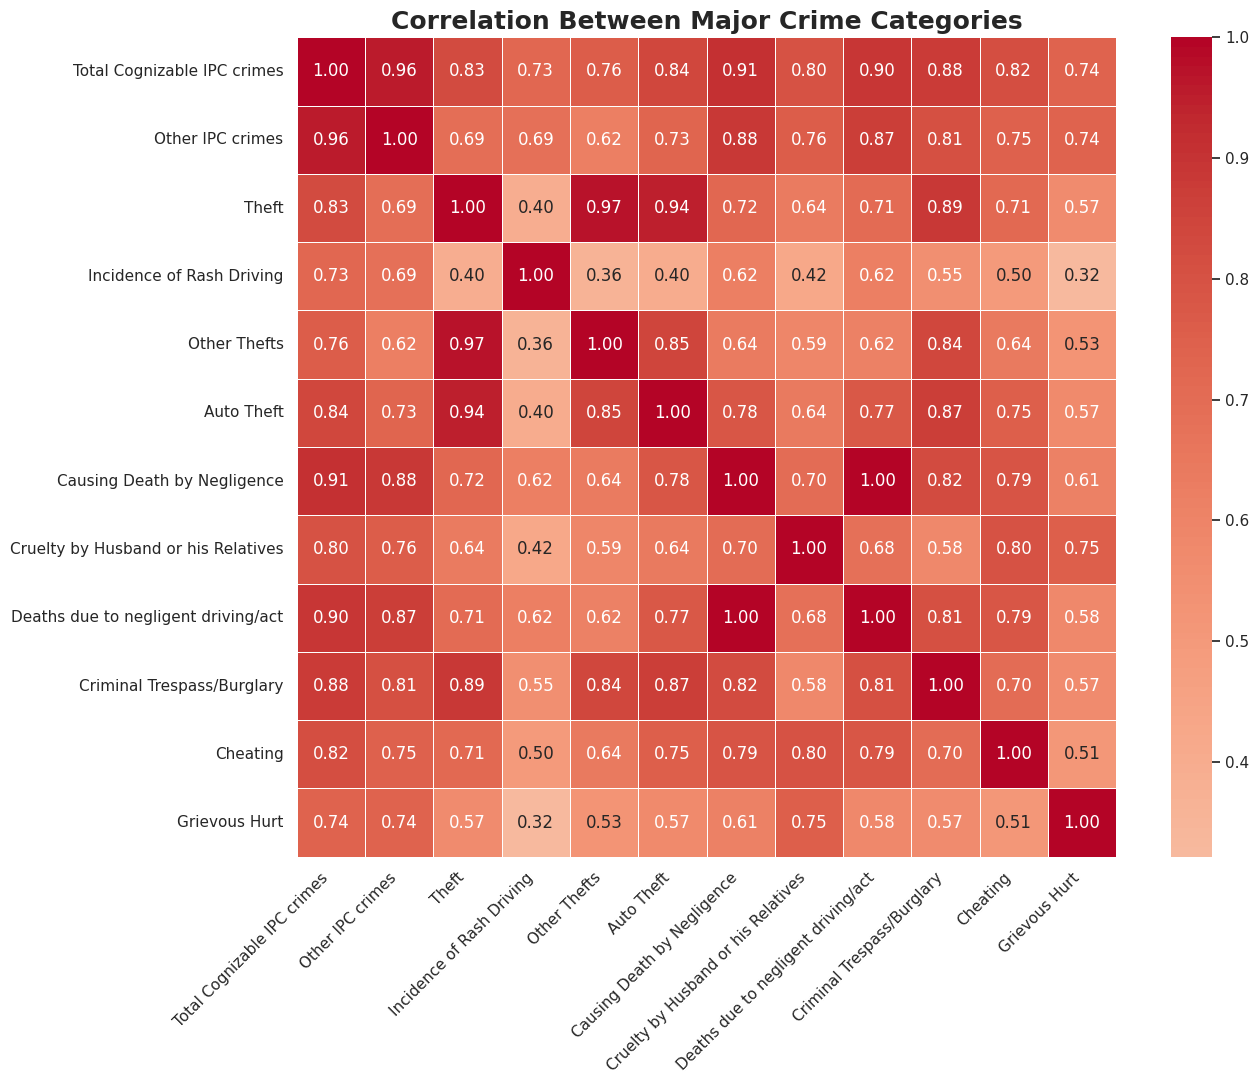

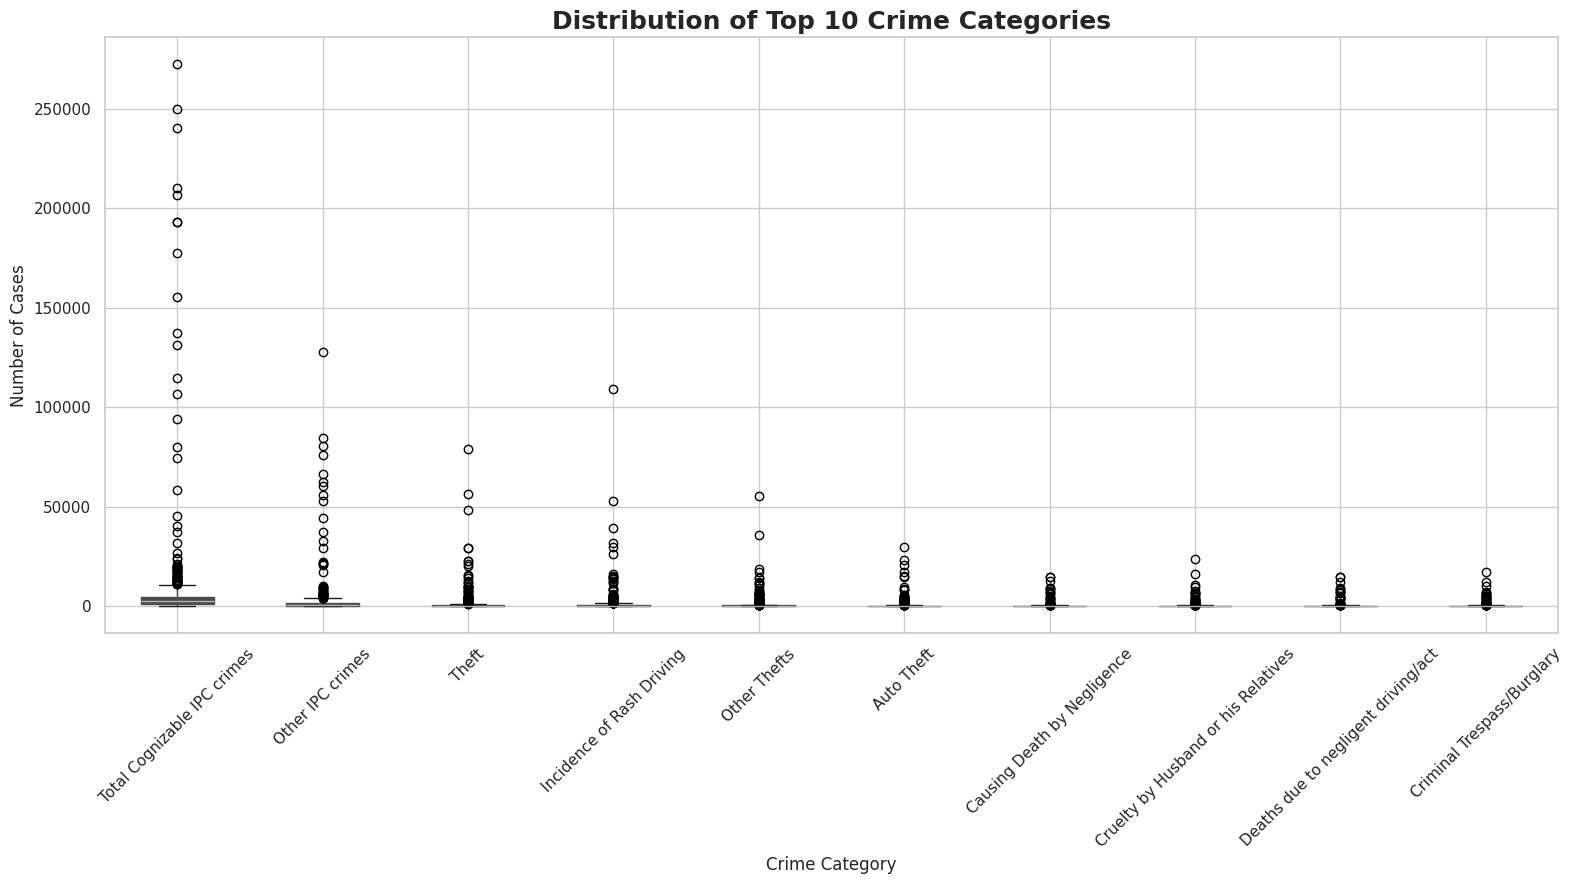

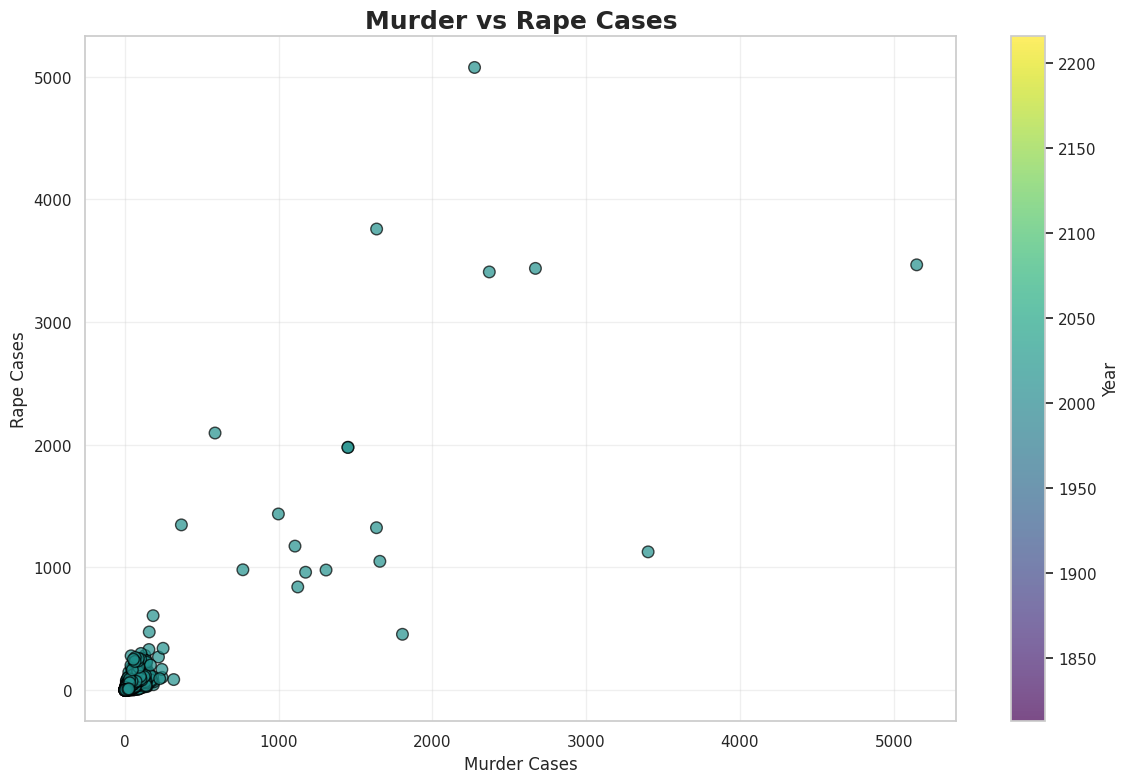

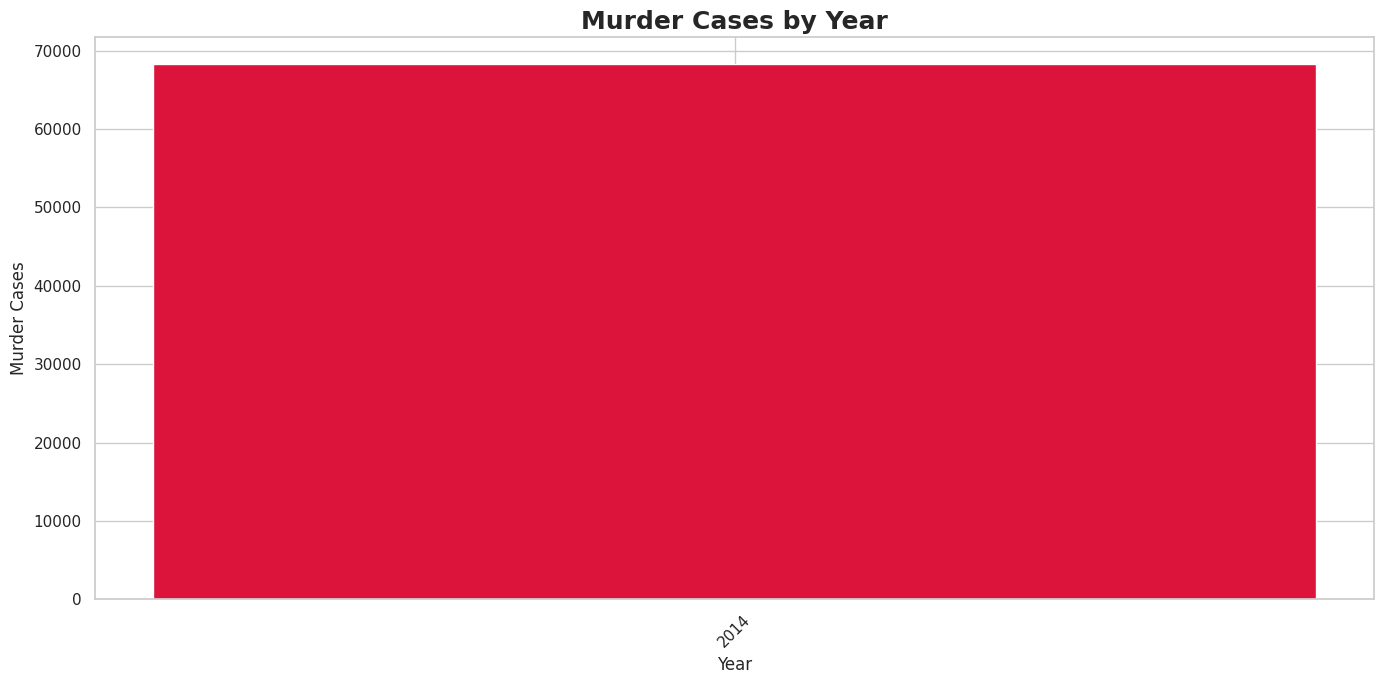

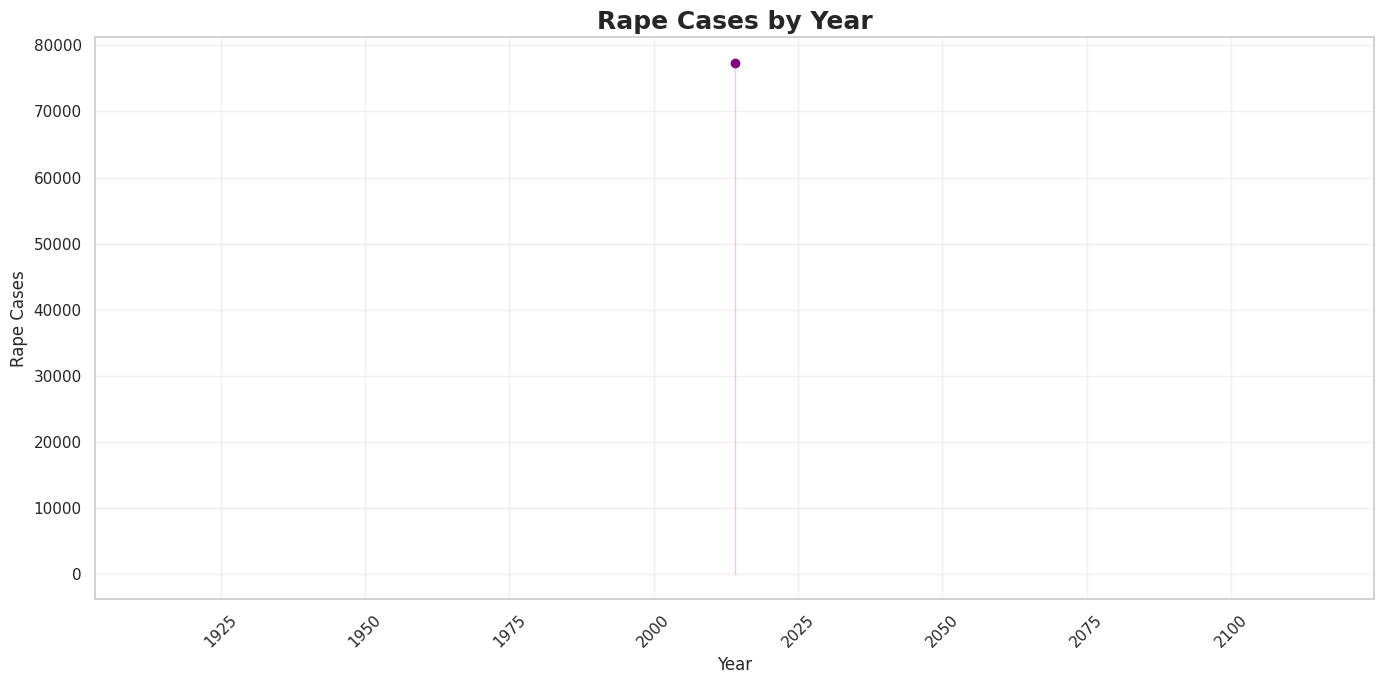

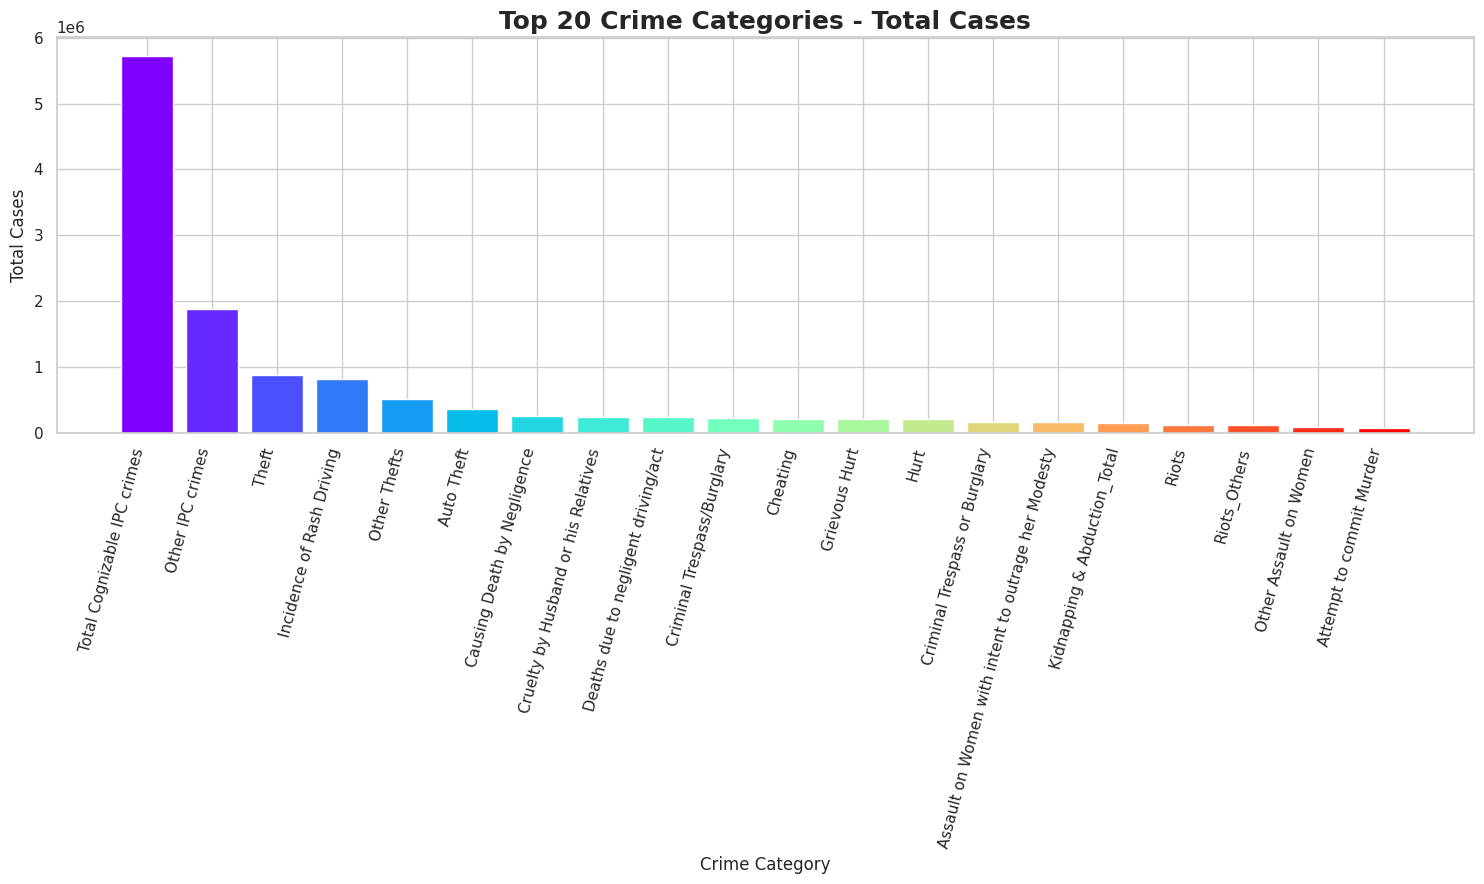

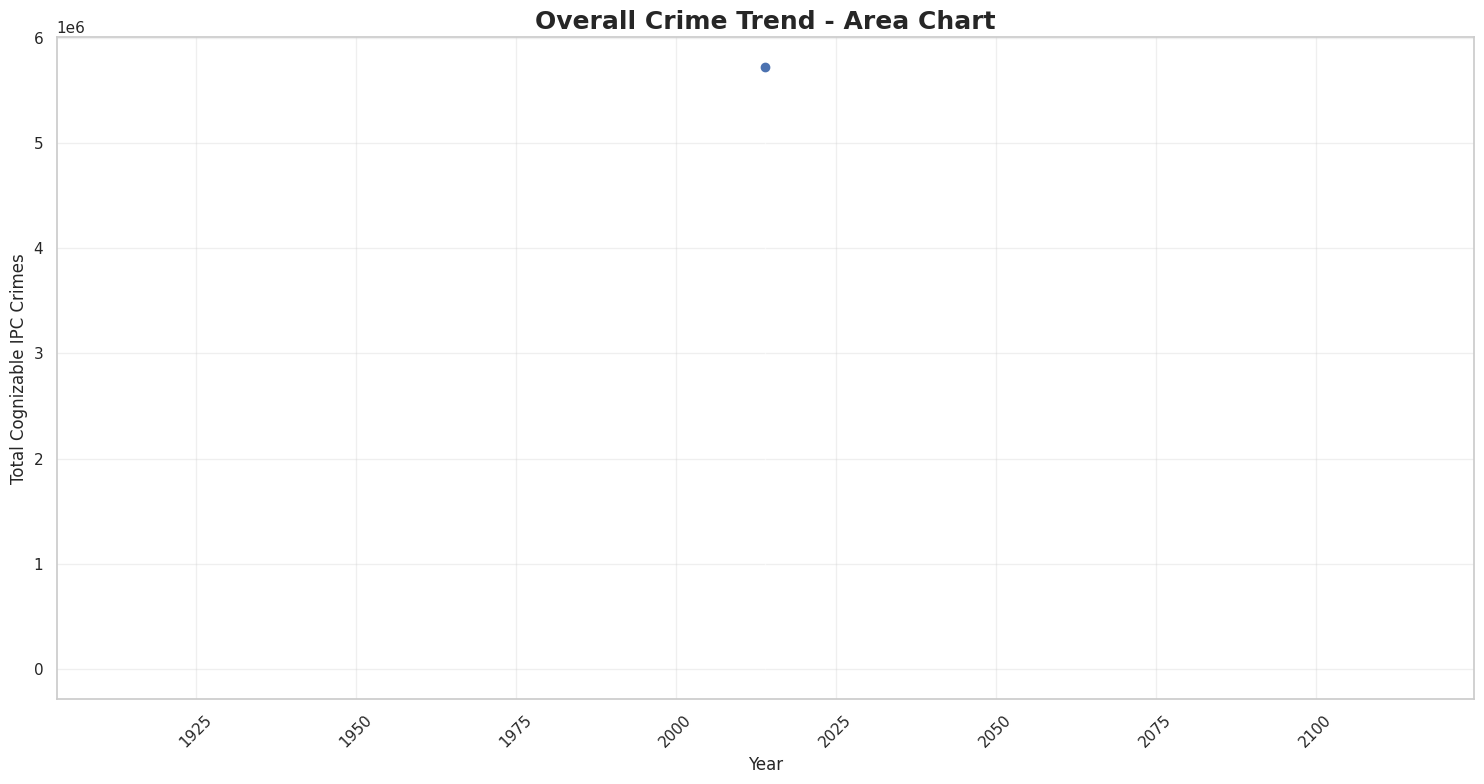

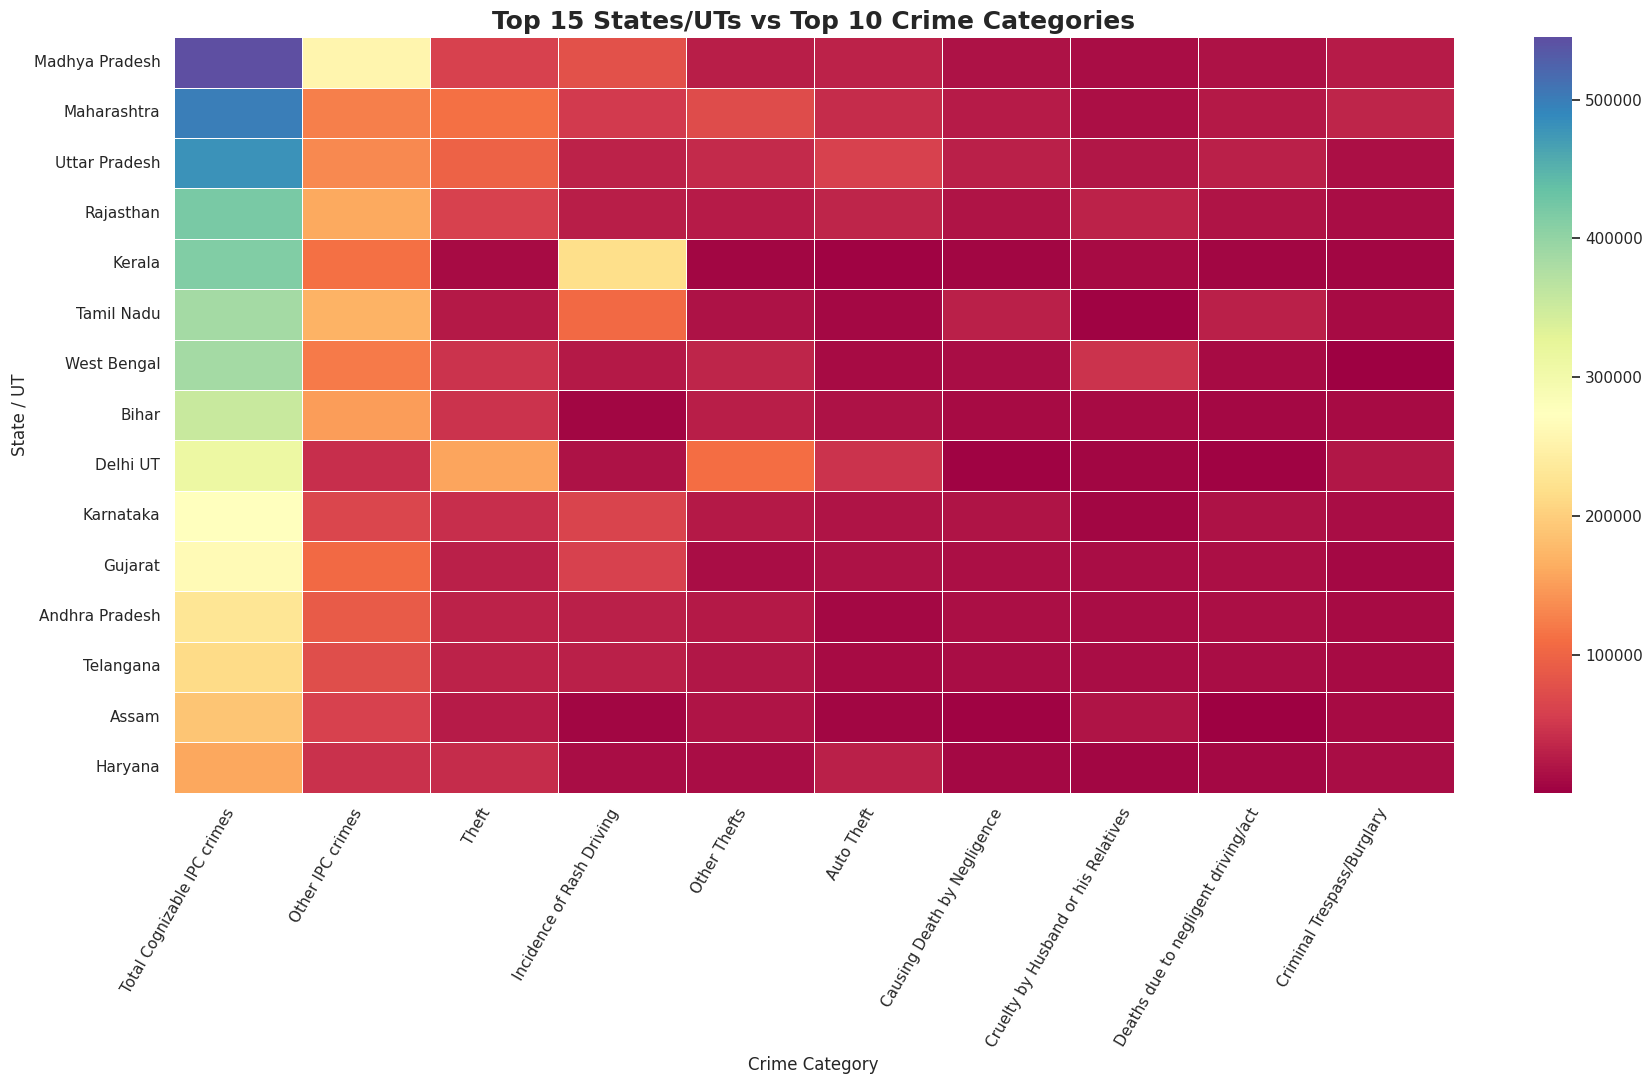



CRIME DATASET VISUALIZATION SUMMARY

Top 10 Crime Categories:
Total Cognizable IPC crimes            5717878
Other IPC crimes                       1888210
Theft                                   884928
Incidence of Rash Driving               819714
Other Thefts                            512858
Auto Theft                              372070
Causing Death by Negligence             257674
Cruelty by Husband or his Relatives     246326
Deaths due to negligent driving/act     244764
Criminal Trespass/Burglary              229334
dtype: int64


Year Range:
2014 to 2014

Number of States/UTs: 36
Number of Districts: 783

Total Crime Columns: 88

VISUALIZATION COMPLETED SUCCESSFULLY


In [13]:

# ------------------------------------------------------------
# 1. BASIC SETTINGS
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

# Make sure Year is numeric
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Identify crime columns
id_columns = ["States/UTs", "District", "Year"]

crime_columns = [
    col for col in df.columns
    if col not in id_columns
]

# Convert crime columns to numeric
for col in crime_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing numeric values
df[crime_columns] = df[crime_columns].fillna(0)

print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(df.isnull().sum().sort_values(ascending=False).head(20))


# ============================================================
# 2. TOP CRIME CATEGORIES - TOTAL
# ============================================================

crime_totals = df[crime_columns].sum().sort_values(ascending=False)

top_15 = crime_totals.head(15)

plt.figure(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(top_15)))

bars = plt.barh(
    top_15.index[::-1],
    top_15.values[::-1],
    color=colors
)

plt.title(
    "Top 15 Crime Categories by Total Reported Cases",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Total Number of Cases", fontsize=12)
plt.ylabel("Crime Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ============================================================
# 3. TOTAL COGNIZABLE IPC CRIMES BY YEAR
# ============================================================

if "Total Cognizable IPC crimes" in df.columns:

    yearly_crime = (
        df.groupby("Year")["Total Cognizable IPC crimes"]
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(14, 7))

    plt.plot(
        yearly_crime.index,
        yearly_crime.values,
        marker="o",
        linewidth=3,
        color="darkblue"
    )

    plt.fill_between(
        yearly_crime.index,
        yearly_crime.values,
        alpha=0.20
    )

    plt.title(
        "Total Cognizable IPC Crimes Over the Years",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Total Crimes", fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. TOP 10 STATES/UTs BY TOTAL CRIME
# ============================================================

if "States/UTs" in df.columns and "Total Cognizable IPC crimes" in df.columns:

    state_crime = (
        df.groupby("States/UTs")["Total Cognizable IPC crimes"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(14, 8))

    colors = plt.cm.Set3(
        np.linspace(0, 1, len(state_crime))
    )

    bars = plt.bar(
        state_crime.index,
        state_crime.values,
        color=colors
    )

    plt.title(
        "Top 10 States/UTs by Total Cognizable IPC Crimes",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("State / UT", fontsize=12)
    plt.ylabel("Total Crimes", fontsize=12)

    plt.xticks(rotation=45, ha="right")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. TOP 10 DISTRICTS BY TOTAL CRIME
# ============================================================

if "District" in df.columns and "Total Cognizable IPC crimes" in df.columns:

    district_crime = (
        df.groupby("District")["Total Cognizable IPC crimes"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(14, 8))

    colors = plt.cm.Paired(
        np.linspace(0, 1, len(district_crime))
    )

    bars = plt.barh(
        district_crime.index[::-1],
        district_crime.values[::-1],
        color=colors
    )

    plt.title(
        "Top 10 Districts by Total Cognizable IPC Crimes",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Crimes")
    plt.ylabel("District")

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. TOP 10 CRIMES - PIE CHART
# ============================================================

top_10 = crime_totals.head(10)

plt.figure(figsize=(11, 11))

colors = plt.cm.tab10(
    np.linspace(0, 1, len(top_10))
)

plt.pie(
    top_10.values,
    labels=top_10.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.75
)

plt.title(
    "Distribution of Top 10 Crime Categories",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. TOP 10 CRIMES - DONUT CHART
# ============================================================

plt.figure(figsize=(11, 11))

colors = plt.cm.Set2(
    np.linspace(0, 1, len(top_10))
)

plt.pie(
    top_10.values,
    labels=top_10.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title(
    "Top 10 Crime Categories - Donut Chart",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. YEARLY TREND OF TOP 5 CRIMES
# ============================================================

top_5_crimes = crime_totals.head(5).index

yearly_top5 = (
    df.groupby("Year")[top_5_crimes]
    .sum()
    .sort_index()
)

plt.figure(figsize=(15, 8))

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple"
]

for i, crime in enumerate(top_5_crimes):

    plt.plot(
        yearly_top5.index,
        yearly_top5[crime],
        marker="o",
        linewidth=2.5,
        label=crime,
        color=colors[i]
    )

plt.title(
    "Yearly Trend of Top 5 Crime Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 9. TOP 10 STATES - STACKED CRIME CATEGORY CHART
# ============================================================

if "States/UTs" in df.columns:

    top_states = (
        df.groupby("States/UTs")["Total Cognizable IPC crimes"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    state_data = (
        df[df["States/UTs"].isin(top_states)]
        .groupby("States/UTs")[top_5_crimes]
        .sum()
    )

    state_data = state_data.loc[top_states]

    ax = state_data.plot(
        kind="bar",
        stacked=True,
        figsize=(16, 9),
        colormap="tab10"
    )

    plt.title(
        "Top 10 States/UTs - Top 5 Crime Categories",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("State / UT")
    plt.ylabel("Number of Cases")

    plt.xticks(rotation=45, ha="right")

    plt.legend(
        title="Crime Category",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. HEATMAP - TOP 15 CRIMES
# ============================================================

top_15_crimes = crime_totals.head(15).index

heatmap_data = (
    df.groupby("Year")[top_15_crimes]
    .sum()
)

plt.figure(figsize=(18, 10))

sns.heatmap(
    heatmap_data.T,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=False
)

plt.title(
    "Crime Category Heatmap Across Years",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Crime Category")

plt.tight_layout()
plt.show()


# ============================================================
# 11. CORRELATION HEATMAP
# ============================================================

top_12_crimes = crime_totals.head(12).index

corr = df[top_12_crimes].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Between Major Crime Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 12. BOX PLOT - TOP 10 CRIMES
# ============================================================

box_data = df[top_10.index]

plt.figure(figsize=(16, 9))

box_data.boxplot(
    rot=45,
    patch_artist=True
)

plt.title(
    "Distribution of Top 10 Crime Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Crime Category")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()


# ============================================================
# 13. SCATTER PLOT - TWO MAJOR CRIMES
# ============================================================

if (
    "Murder" in df.columns
    and "Rape" in df.columns
):

    plt.figure(figsize=(12, 8))

    scatter = plt.scatter(
        df["Murder"],
        df["Rape"],
        c=df["Year"],
        cmap="viridis",
        s=70,
        alpha=0.7,
        edgecolors="black"
    )

    plt.colorbar(scatter, label="Year")

    plt.title(
        "Murder vs Rape Cases",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Murder Cases")
    plt.ylabel("Rape Cases")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. MURDER TREND BY YEAR
# ============================================================

if "Murder" in df.columns:

    murder_year = (
        df.groupby("Year")["Murder"]
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(14, 7))

    plt.bar(
        murder_year.index.astype(str),
        murder_year.values,
        color="crimson"
    )

    plt.title(
        "Murder Cases by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Year")
    plt.ylabel("Murder Cases")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 15. RAPE TREND BY YEAR
# ============================================================

if "Rape" in df.columns:

    rape_year = (
        df.groupby("Year")["Rape"]
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(14, 7))

    plt.plot(
        rape_year.index,
        rape_year.values,
        marker="o",
        linewidth=3,
        color="purple"
    )

    plt.fill_between(
        rape_year.index,
        rape_year.values,
        alpha=0.2,
        color="purple"
    )

    plt.title(
        "Rape Cases by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Year")
    plt.ylabel("Rape Cases")

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. CRIME CATEGORY CONTRIBUTION
# ============================================================

top_20 = crime_totals.head(20)

plt.figure(figsize=(15, 9))

colors = plt.cm.rainbow(
    np.linspace(0, 1, len(top_20))
)

bars = plt.bar(
    range(len(top_20)),
    top_20.values,
    color=colors
)

plt.title(
    "Top 20 Crime Categories - Total Cases",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Crime Category")
plt.ylabel("Total Cases")

plt.xticks(
    range(len(top_20)),
    top_20.index,
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. YEARLY TOTAL CRIME - AREA CHART
# ============================================================

if "Total Cognizable IPC crimes" in df.columns:

    yearly_total = (
        df.groupby("Year")["Total Cognizable IPC crimes"]
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(15, 8))

    plt.fill_between(
        yearly_total.index,
        yearly_total.values,
        alpha=0.5
    )

    plt.plot(
        yearly_total.index,
        yearly_total.values,
        marker="o",
        linewidth=3
    )

    plt.title(
        "Overall Crime Trend - Area Chart",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Year")
    plt.ylabel("Total Cognizable IPC Crimes")

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. TOP 10 CRIMES BY STATE - HEATMAP
# ============================================================

if "States/UTs" in df.columns:

    state_crime_heatmap = (
        df.groupby("States/UTs")[top_10.index]
        .sum()
    )

    top_states_for_heatmap = (
        df.groupby("States/UTs")["Total Cognizable IPC crimes"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    state_crime_heatmap = state_crime_heatmap.loc[
        top_states_for_heatmap
    ]

    plt.figure(figsize=(18, 11))

    sns.heatmap(
        state_crime_heatmap,
        cmap="Spectral",
        linewidths=0.4
    )

    plt.title(
        "Top 15 States/UTs vs Top 10 Crime Categories",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Crime Category")
    plt.ylabel("State / UT")

    plt.xticks(rotation=60, ha="right")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. CRIME STATISTICS SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("CRIME DATASET VISUALIZATION SUMMARY")
print("=" * 80)

print("\nTop 10 Crime Categories:")
print(top_10)

print("\n")

if "Year" in df.columns:
    print("Year Range:")
    print(
        int(df["Year"].min()),
        "to",
        int(df["Year"].max())
    )

print("\nNumber of States/UTs:",
      df["States/UTs"].nunique()
      if "States/UTs" in df.columns else "N/A")

print("Number of Districts:",
      df["District"].nunique()
      if "District" in df.columns else "N/A")

print("\nTotal Crime Columns:", len(crime_columns))

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 80)

## Feature engineering

DATASET INFORMATION
Rows    : 838
Columns : 91

Columns:
['States/UTs', 'District', 'Year', 'Murder', 'Attempt to commit Murder', 'Culpable Homicide not amounting to Murder', 'Attempt to commit Culpable Homicide', 'Rape', 'Custodial Rape', 'Custodial_Gang Rape', 'Custodial_Other Rape', 'Rape other than Custodial', 'Rape_Gang Rape', 'Rape_Others', 'Attempt to commit Rape', 'Kidnapping & Abduction_Total', 'Kidnapping & Abduction', 'Kidnapping & Abduction in order to Murder', 'Kidnapping for Ransom', 'Kidnapping & Abduction of Women to compel her for marriage', 'Other Kidnapping', 'Dacoity', 'Dacoity with Murder', 'Other Dacoity', 'Making Preparation and Assembly for committing Dacoity', 'Robbery', 'Criminal Trespass/Burglary', 'Criminal Trespass or Burglary', 'House Trespass & House Breaking', 'Theft', 'Auto Theft', 'Other Thefts', 'Unlawful Assembly', 'Riots', 'Riots_Communal', 'Riots_Industrial', 'Riots_Political', 'Riots_Caste Conflict', 'Riots_SC/STs Vs Non-SCs/STs', 'Riots_Other Cas

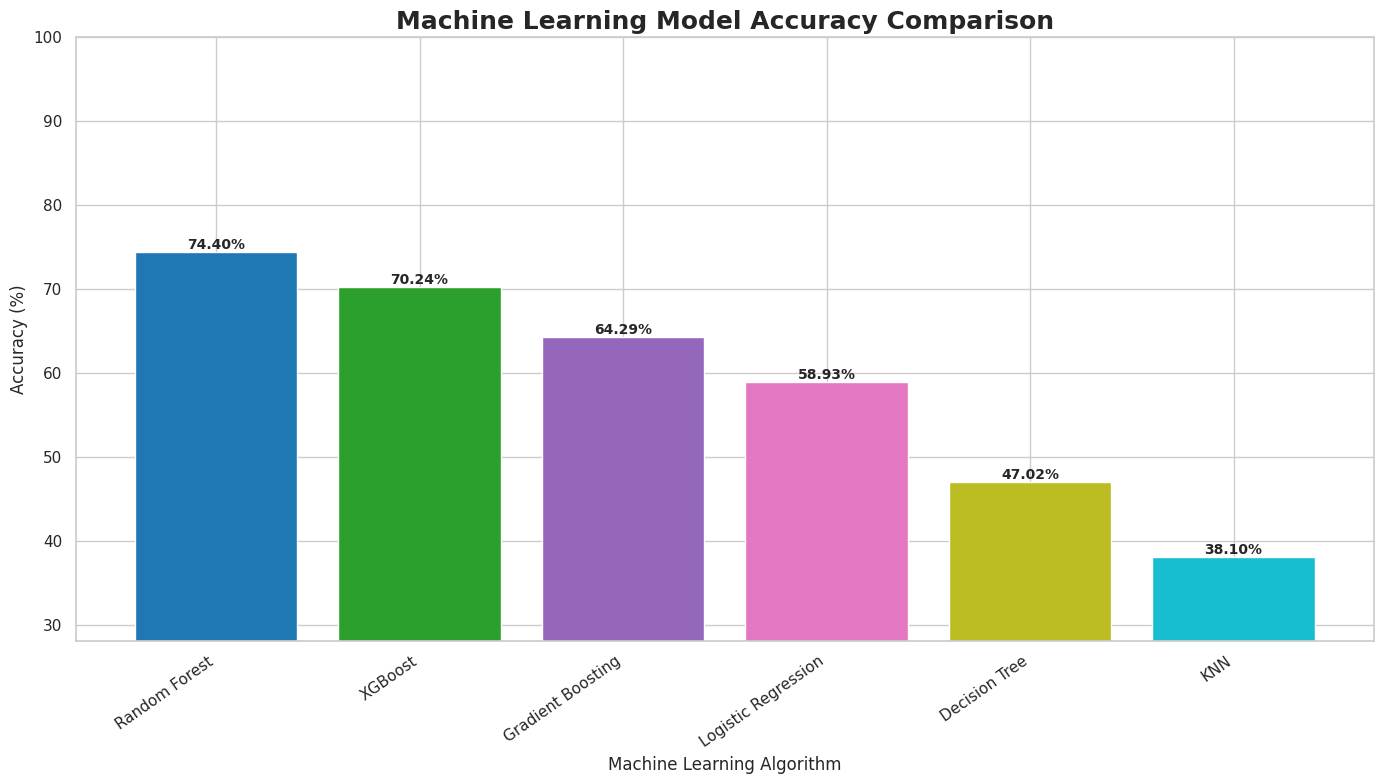

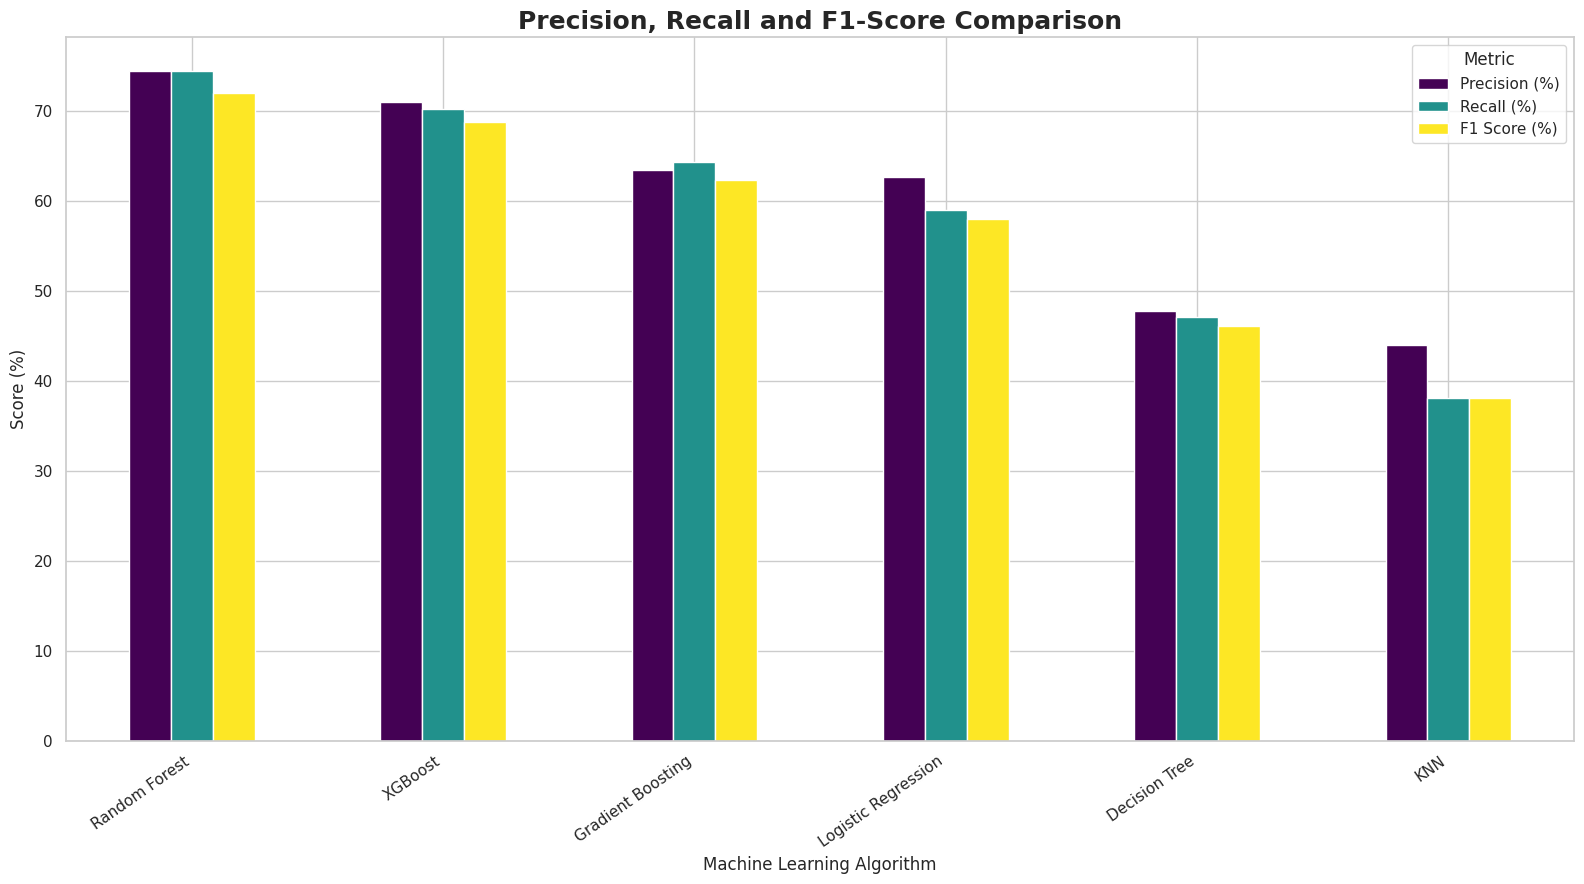





LOGISTIC REGRESSION
                   precision    recall  f1-score   support

      A&N Islands       0.00      0.00      0.00         1
   Andhra Pradesh       0.29      0.50      0.36         4
Arunachal Pradesh       0.00      0.00      0.00         4
            Assam       0.80      0.67      0.73         6
            Bihar       0.89      0.80      0.84        10
     Chhattisgarh       0.00      0.00      0.00         6
      Daman & Diu       0.00      0.00      0.00         1
         Delhi UT       0.67      0.50      0.57         4
              Goa       0.00      0.00      0.00         1
          Gujarat       0.50      0.56      0.53         9
          Haryana       0.75      0.60      0.67         5
 Himachal Pradesh       0.00      0.00      0.00         3
  Jammu & Kashmir       0.16      0.83      0.27         6
        Jharkhand       1.00      0.60      0.75         5
        Karnataka       0.71      0.71      0.71         7
           Kerala       1.00   

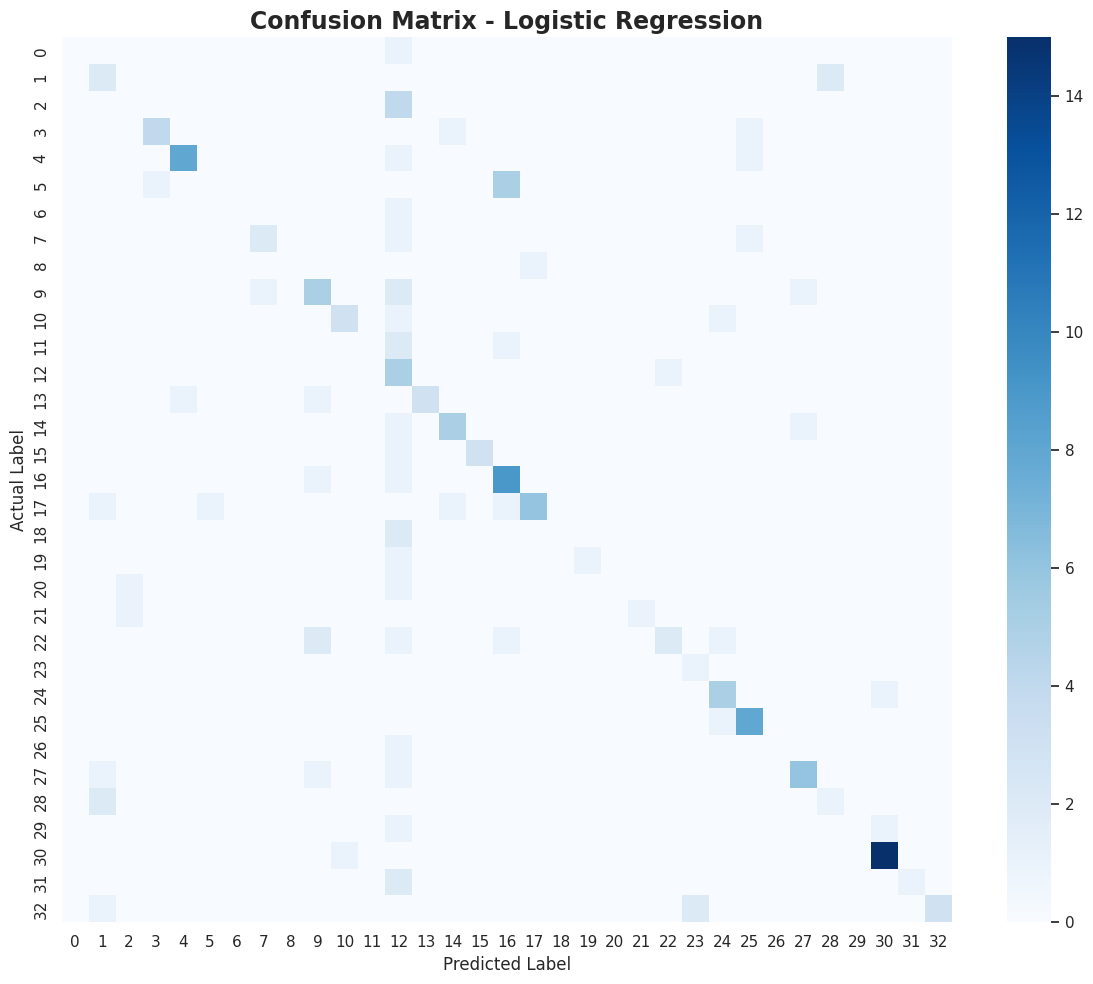

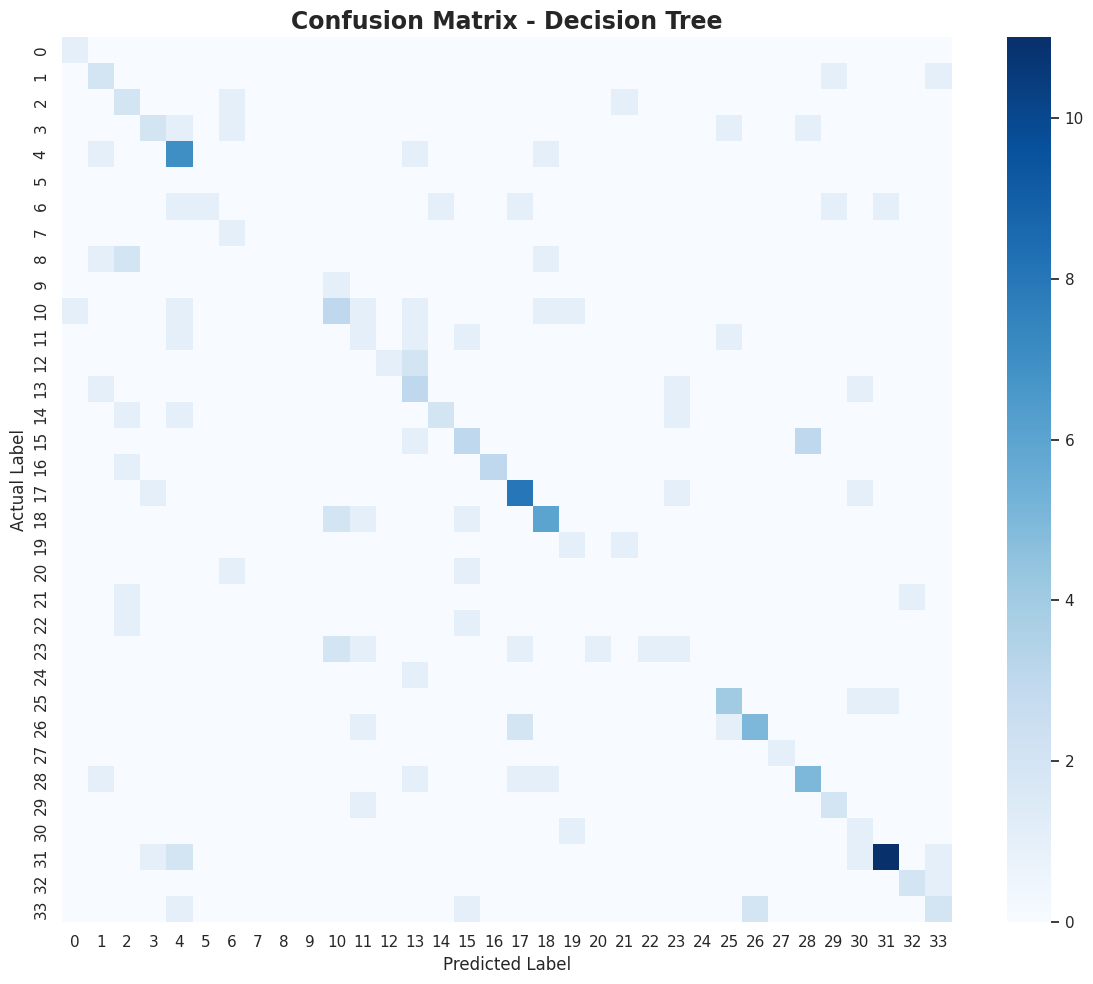

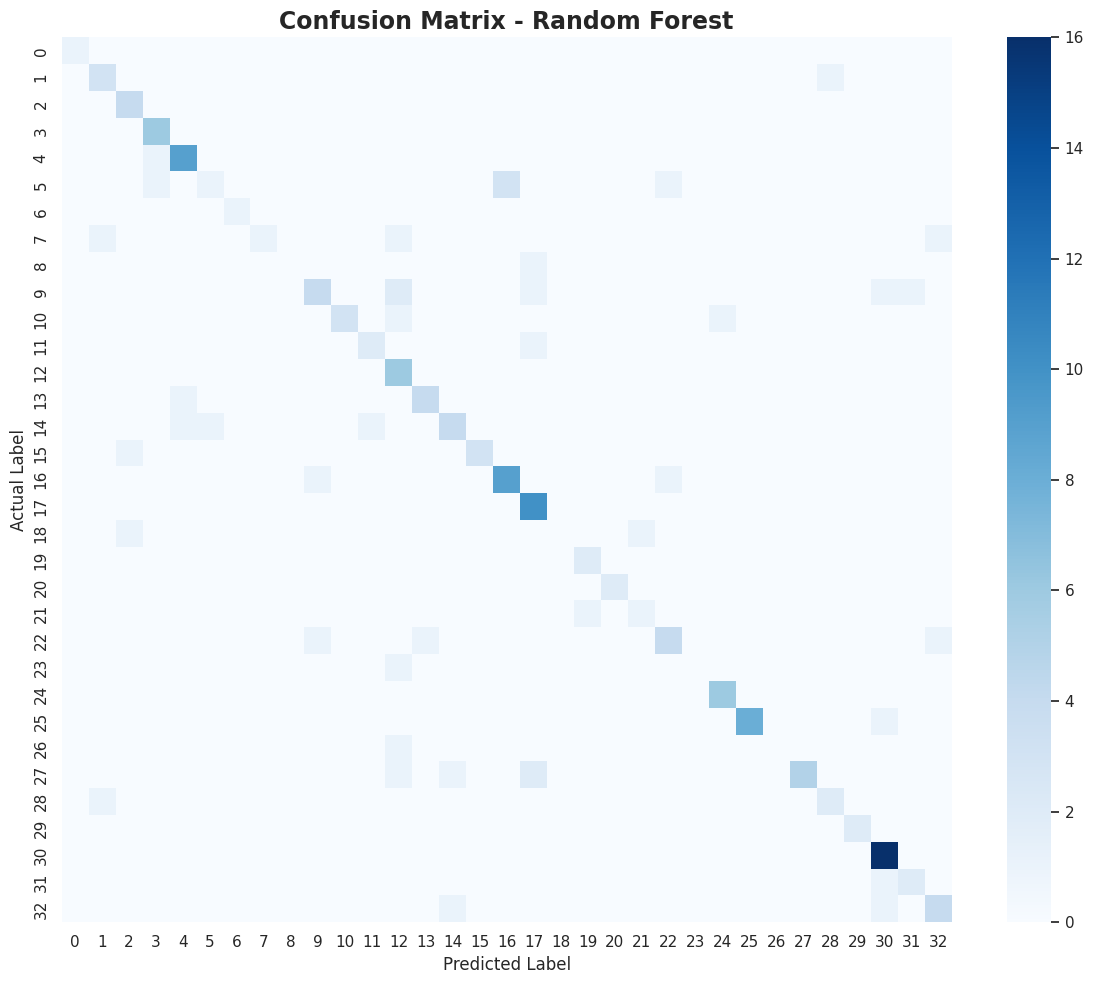

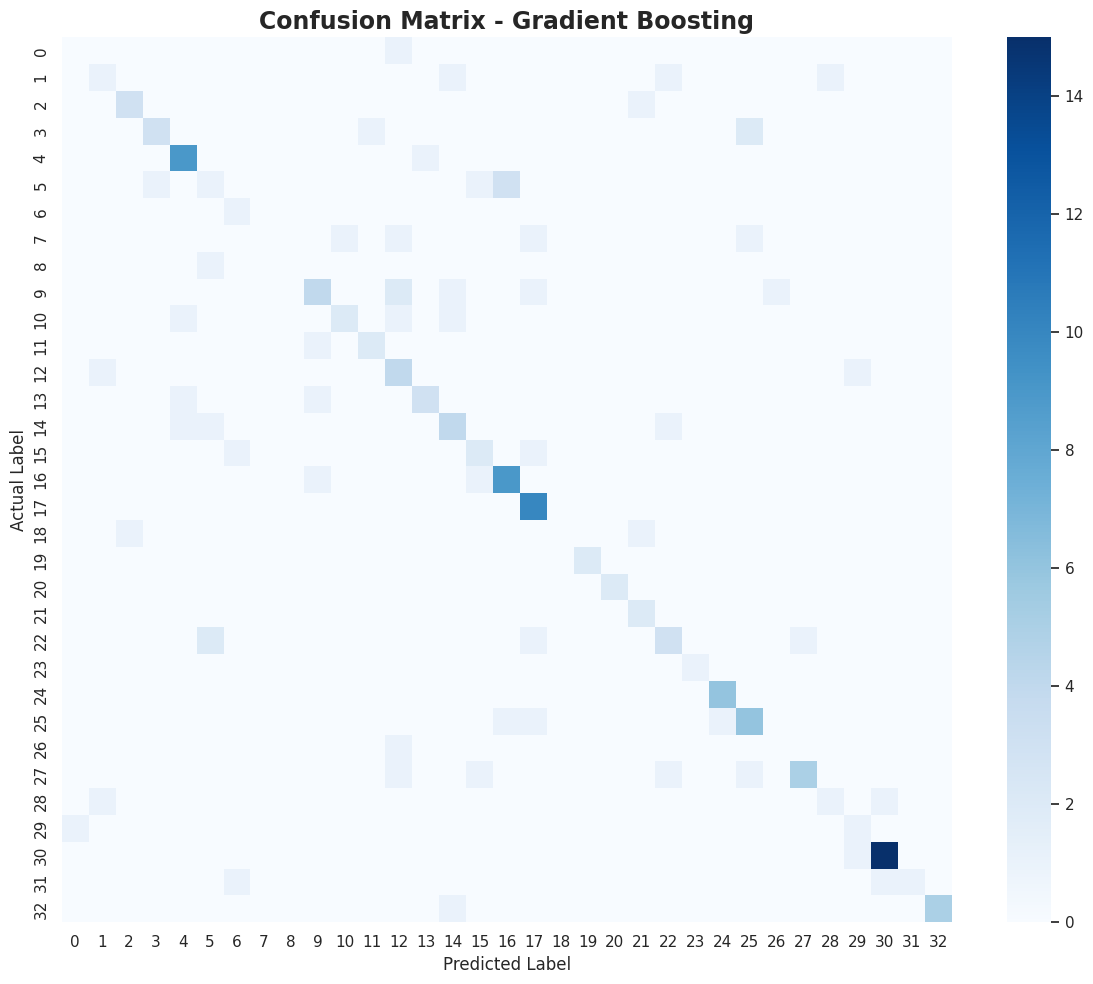

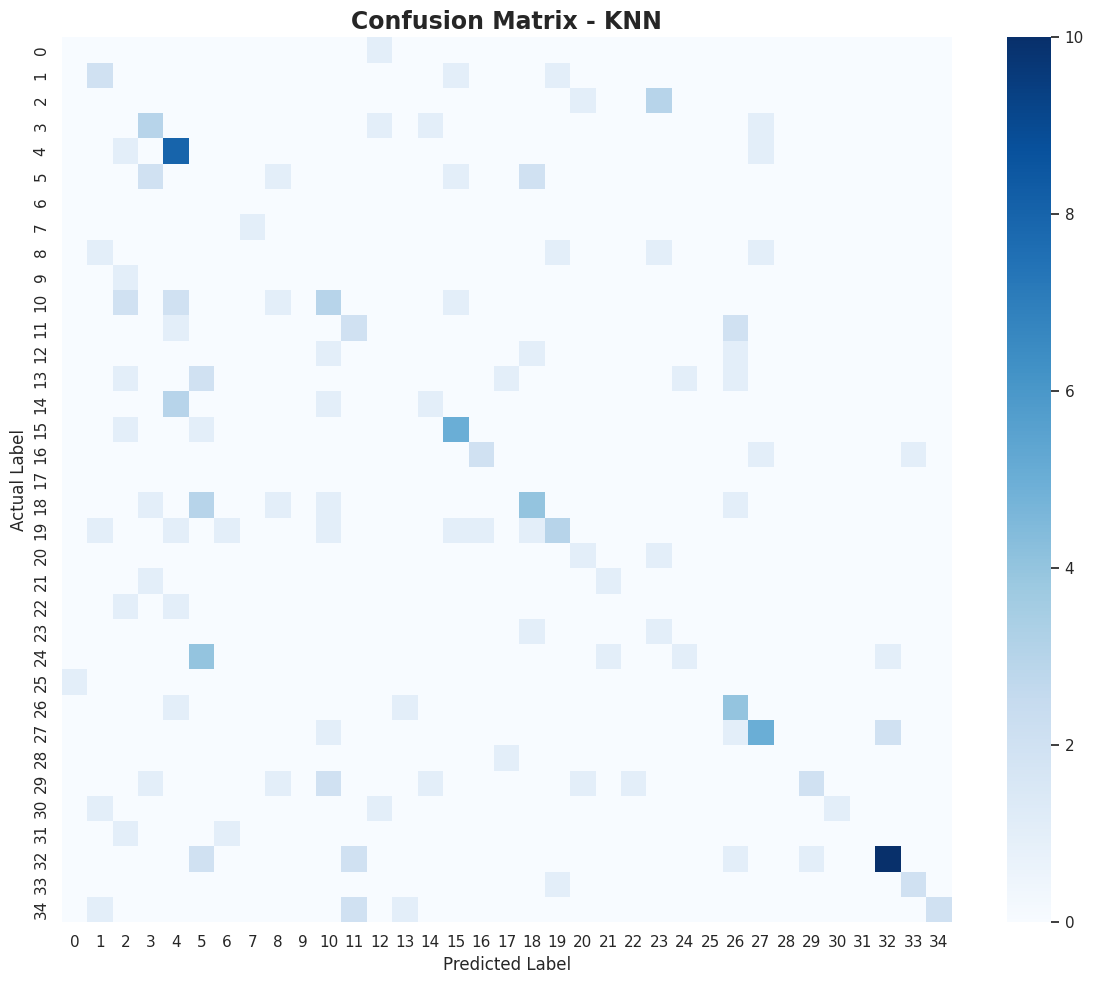

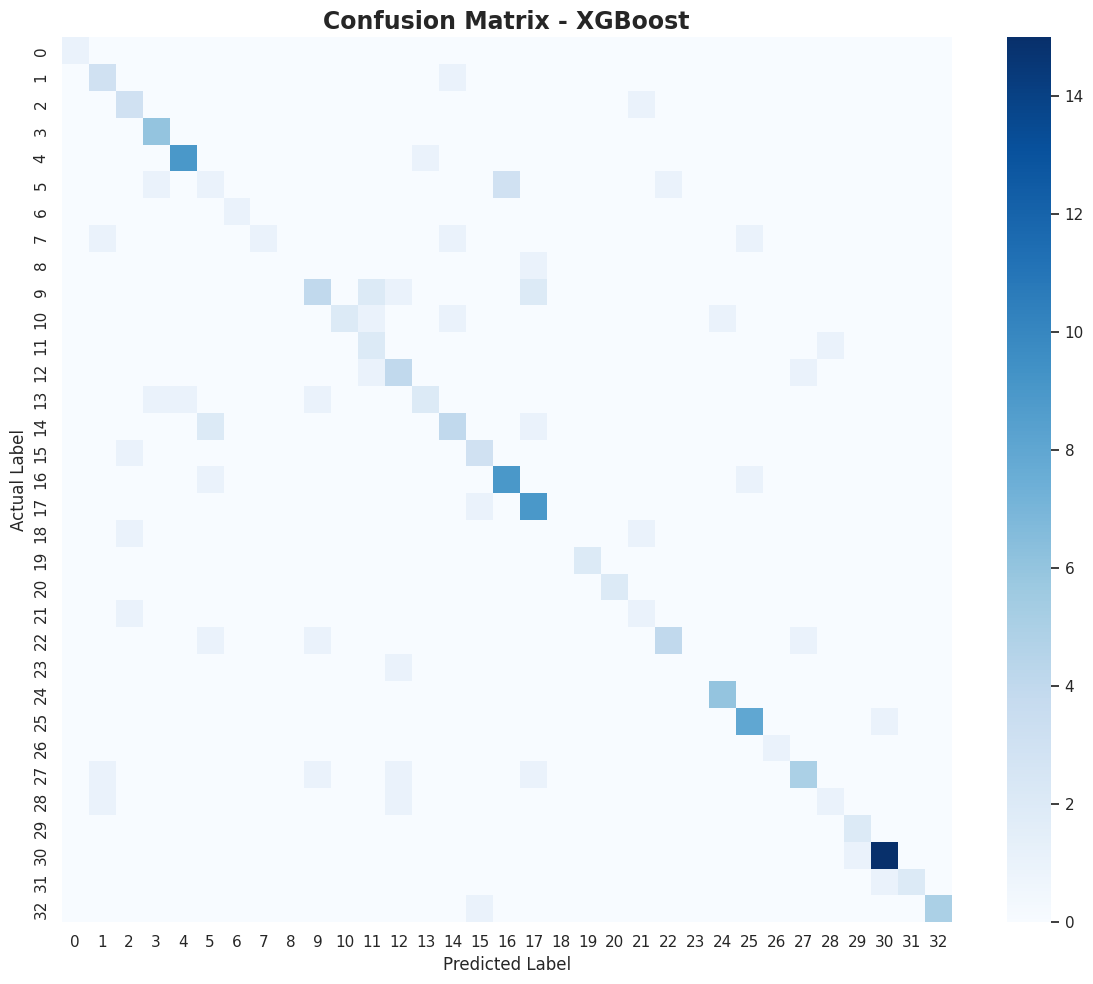



MULTICLASS ROC-AUC
Logistic Regression: 0.9206
Decision Tree: 0.7455
Random Forest: 0.9294
Gradient Boosting: 0.9331
KNN: 0.7915
XGBoost: 0.9654


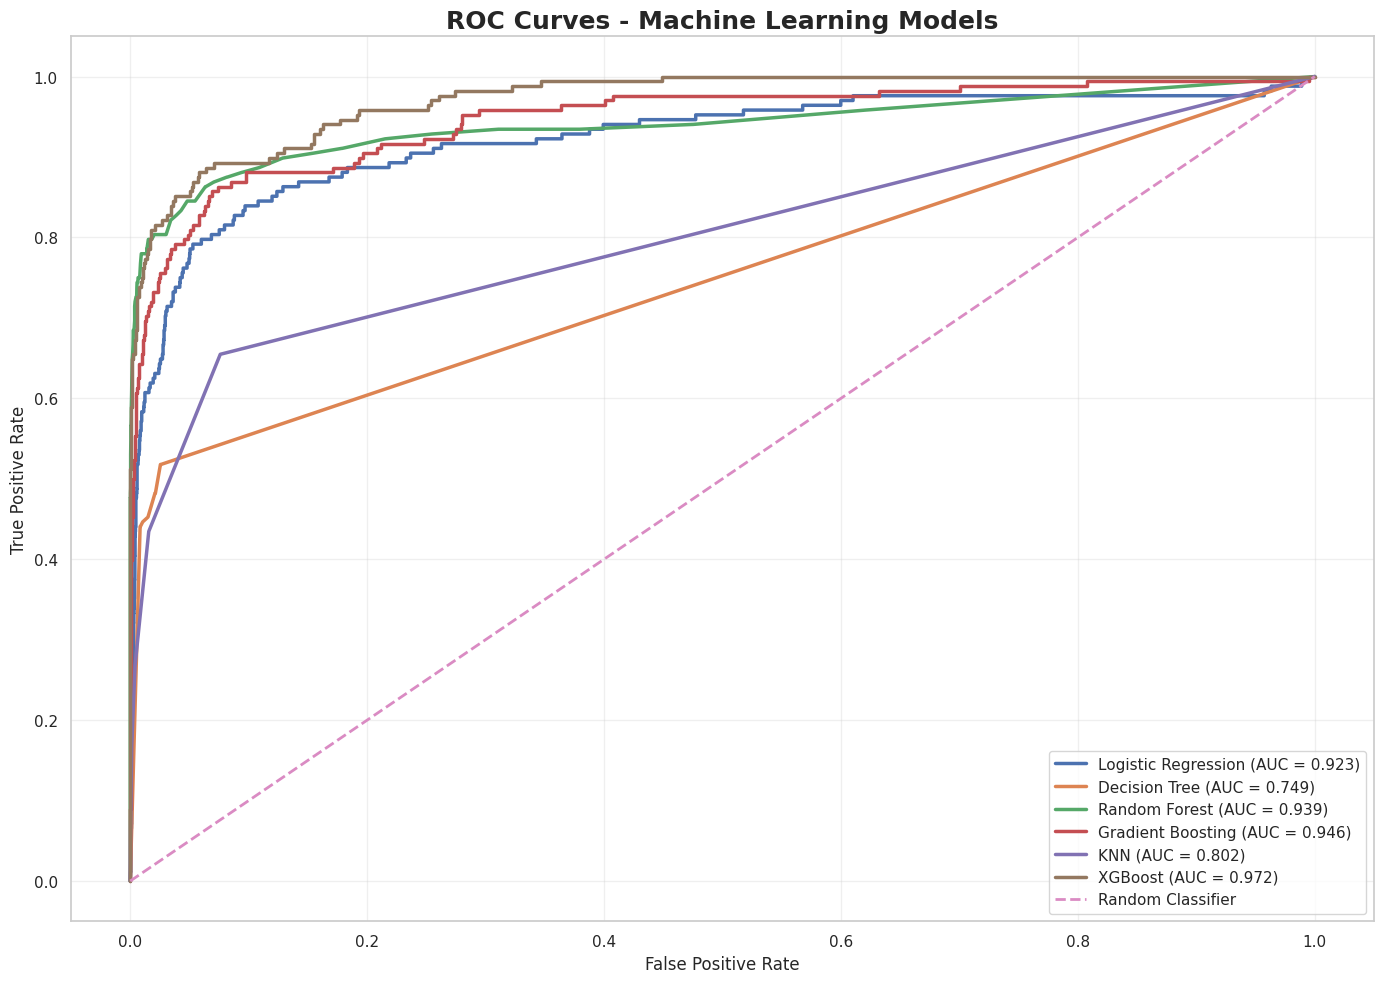



BEST PERFORMING MODEL BY TEST ACCURACY
Model: Random Forest
Accuracy: 74.40%


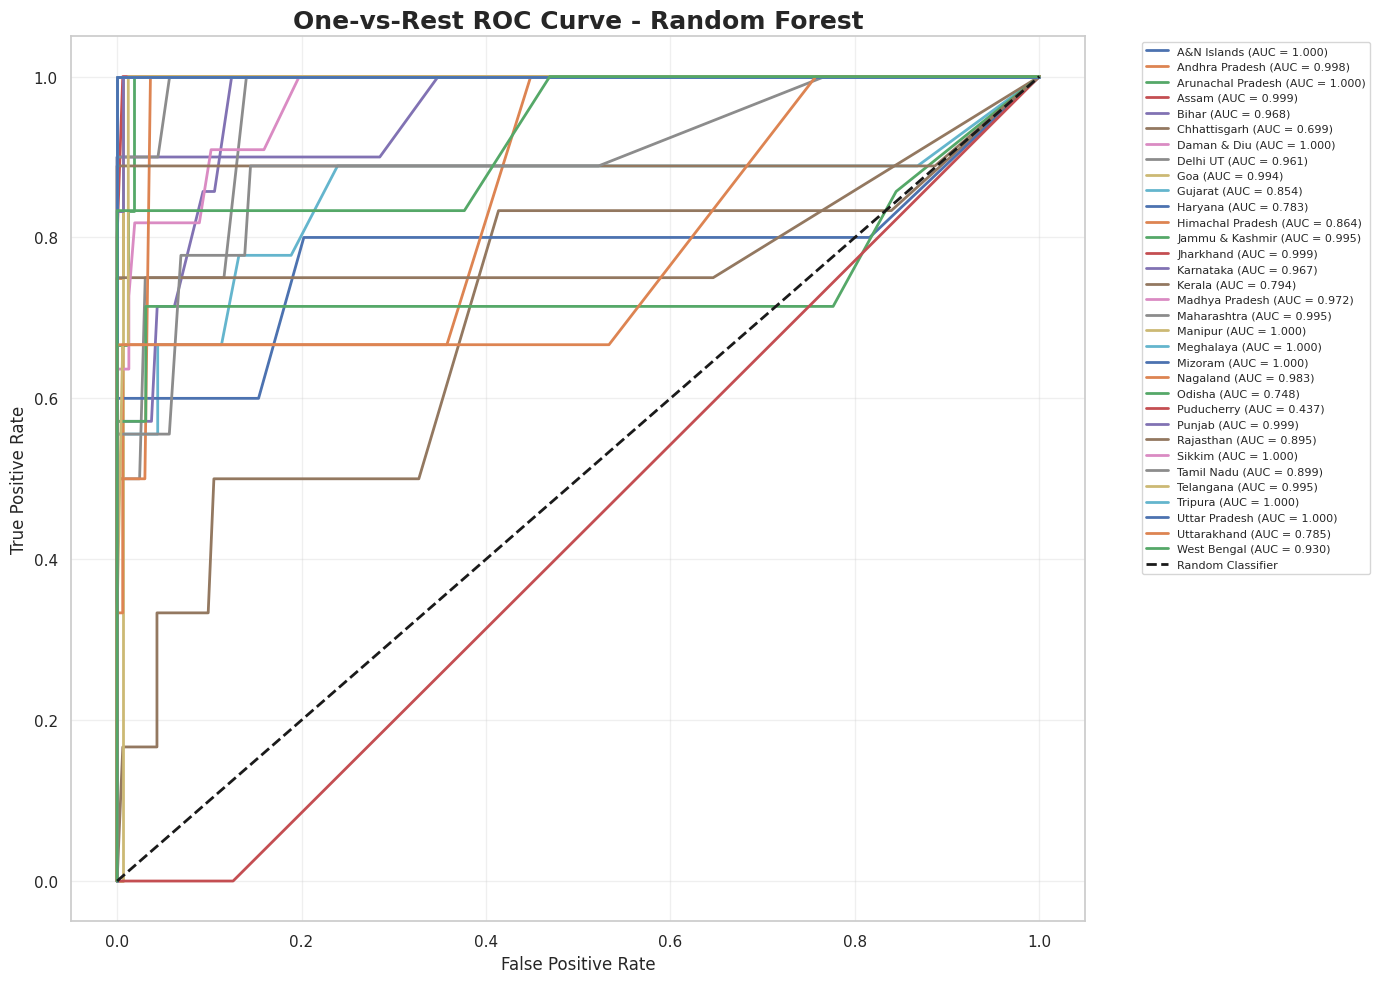



TOP 20 RANDOM FOREST FEATURES
                                                     Feature  Importance
                                              numeric__Riots    0.030653
                          numeric__Incidence of Rash Driving    0.029371
                                           numeric__Cheating    0.029366
numeric__Assault on Women with intent to outrage her Modesty    0.028305
                                       numeric__Riots_Others    0.028045
                                   numeric__Other IPC crimes    0.026664
          numeric__Culpable Homicide not amounting to Murder    0.026517
                        numeric__Total Cognizable IPC crimes    0.025743
                                       numeric__Dowry Deaths    0.024779
                numeric__Cruelty by Husband or his Relatives    0.024434
                       numeric__Kidnapping & Abduction_Total    0.022624
                numeric__Deaths due to negligent driving/act    0.021907
                   

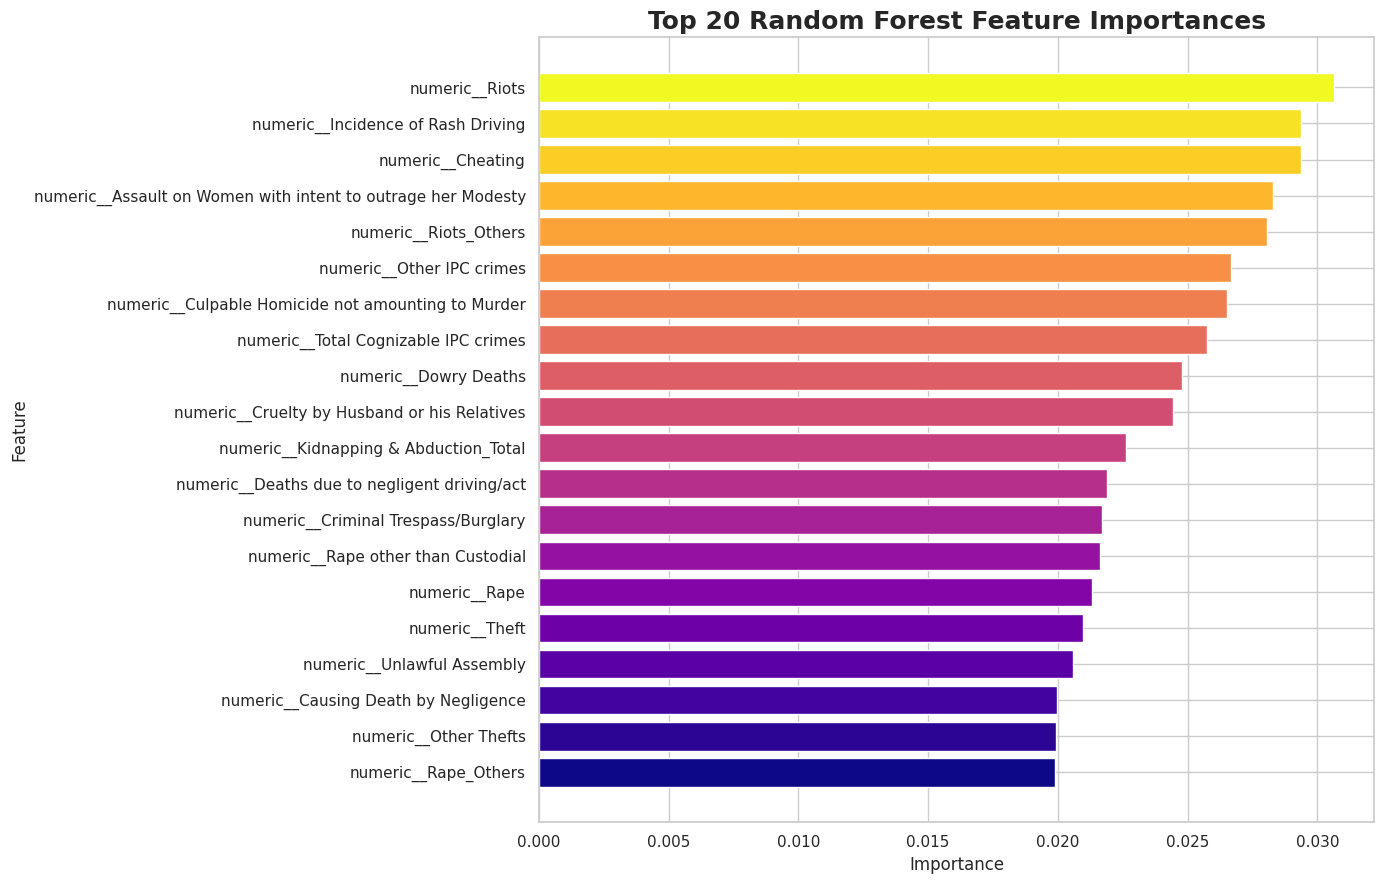



FINAL MACHINE LEARNING RESULTS
              Model Accuracy (%) Precision (%) Recall (%) F1 Score (%)
      Random Forest       74.40%        74.43%     74.40%       71.98%
            XGBoost       70.24%        70.98%     70.24%       68.71%
  Gradient Boosting       64.29%        63.38%     64.29%       62.33%
Logistic Regression       58.93%        62.66%     58.93%       57.96%
      Decision Tree       47.02%        47.73%     47.02%       46.05%
                KNN       38.10%        43.90%     38.10%       38.11%


Model selected based on highest TEST accuracy:
Random Forest
Test Accuracy: 74.40%


MACHINE LEARNING PIPELINE COMPLETED


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not installed. It will be skipped.")


# ============================================================
# 2. COPY DATASET
# ============================================================

data = df.copy()

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

data = data.drop_duplicates().reset_index(drop=True)

print("\nAfter removing duplicates:")
print(data.shape)


# ============================================================
# 4. TARGET VARIABLE
# ============================================================

target = "States/UTs"

if target not in data.columns:
    raise ValueError(
        f"Target column '{target}' was not found in the dataset."
    )


# ============================================================
# 5. REMOVE COLUMNS THAT SHOULD NOT BE USED
# ============================================================

# District can strongly identify the state.
# Removing it prevents target leakage / overly easy prediction.

columns_to_remove = [
    target,
    "District"
]

X = data.drop(
    columns=[
        col for col in columns_to_remove
        if col in data.columns
    ]
)

y = data[target].astype(str)


# ============================================================
# 6. HANDLE NUMERIC COLUMNS
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

# Convert object columns that are actually numeric
for col in X.columns:

    if X[col].dtype == "object":

        converted = pd.to_numeric(
            X[col],
            errors="coerce"
        )

        # If most values can be converted to numeric,
        # treat the column as numeric.
        valid_ratio = converted.notna().mean()

        if valid_ratio > 0.90:
            X[col] = converted


# Recalculate columns after conversion
numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print("Numeric features    :", len(numeric_columns))
print("Categorical features:", len(categorical_columns))

print("\nNumeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


# ============================================================
# 7. LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)

print("Number of classes:", len(class_names))

print("\nEncoded classes:")

for number, class_name in enumerate(class_names):
    print(number, "=", class_name)


# ============================================================
# 8. REMOVE CLASSES WITH ONLY ONE SAMPLE
# ============================================================

# Stratified train/test splitting requires at least
# two samples per class.

class_counts = pd.Series(y_encoded).value_counts()

valid_classes = class_counts[
    class_counts >= 2
].index

valid_mask = np.isin(
    y_encoded,
    valid_classes
)

X = X.loc[valid_mask].reset_index(drop=True)
y_encoded = y_encoded[valid_mask]

print("\nDataset after removing single-sample classes:")
print("Rows:", X.shape[0])


# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print(
    "Training percentage:",
    round(len(X_train) / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage :",
    round(len(X_test) / len(X) * 100, 2),
    "%"
)


# ============================================================
# 10. PREPROCESSING
# ============================================================

# Numeric:
# - Median imputation
# - Standard scaling

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical:
# - Most frequent imputation
# - One-Hot Encoding

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)


# ============================================================
# 11. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}


# ============================================================
# 12. ADD XGBOOST IF AVAILABLE
# ============================================================

if xgb_available:

    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )


# ============================================================
# 13. TRAIN ALL MODELS
# ============================================================

trained_models = {}

results = []

roc_data = {}

print("\n")
print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

for model_name, model in models.items():

    print("\nTraining:", model_name)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Train
    pipeline.fit(
        X_train,
        y_train
    )

    # Predict
    y_pred = pipeline.predict(X_test)

    # Probability
    try:
        y_probability = pipeline.predict_proba(X_test)
    except:
        y_probability = None

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Save model
    trained_models[model_name] = pipeline

    # Save results
    results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })

    print(
        f"{model_name} Accuracy: "
        f"{accuracy * 100:.2f}%"
    )


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}".format,
            "Precision (%)": "{:.2f}".format,
            "Recall (%)": "{:.2f}".format,
            "F1 Score (%)": "{:.2f}".format
        }
    )
)


# ============================================================
# 15. ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(14, 8))

colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(results_df)
    )
)

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"],
    color=colors
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(
    max(0, results_df["Accuracy (%)"].min() - 10),
    100
)

plt.xticks(
    rotation=35,
    ha="right"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 16. PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics_plot = results_df.set_index(
    "Model"
)[
    [
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
]

ax = metrics_plot.plot(
    kind="bar",
    figsize=(16, 9),
    colormap="viridis"
)

plt.title(
    "Precision, Recall and F1-Score Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Score (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Metric"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\n")

for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    print("\n")
    print("=" * 80)
    print(model_name.upper())
    print("=" * 80)

    print(
        classification_report(
            y_test,
            y_pred,
            labels=np.unique(y_test),
            target_names=[
                class_names[i]
                for i in np.unique(y_test)
            ],
            zero_division=0
        )
    )


# ============================================================
# 18. CONFUSION MATRIX FOR EACH MODEL
# ============================================================

for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        fmt="d"
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. MULTICLASS ROC CURVE
# ============================================================

print("\n")
print("=" * 80)
print("MULTICLASS ROC-AUC")
print("=" * 80)

# Only classes appearing in test data
test_classes = np.unique(y_test)

for model_name, pipeline in trained_models.items():

    try:

        y_probability = pipeline.predict_proba(
            X_test
        )

        # ROC-AUC using One-vs-Rest
        roc_auc = roc_auc_score(
            y_test,
            y_probability,
            multi_class="ovr",
            average="weighted",
            labels=pipeline.named_steps[
                "model"
            ].classes_
        )

        print(
            f"{model_name}: "
            f"{roc_auc:.4f}"
        )

    except Exception as e:

        print(
            f"{model_name}: ROC-AUC could not be calculated"
        )


# ============================================================
# 20. ROC CURVES - ONE-VS-REST
# ============================================================

plt.figure(figsize=(14, 10))

for model_name, pipeline in trained_models.items():

    try:

        y_probability = pipeline.predict_proba(
            X_test
        )

        model_classes = pipeline.named_steps[
            "model"
        ].classes_

        # Calculate micro-average ROC
        y_test_binary = np.zeros(
            (
                len(y_test),
                len(model_classes)
            )
        )

        for i, class_value in enumerate(model_classes):

            y_test_binary[:, i] = (
                y_test == class_value
            ).astype(int)

        fpr, tpr, _ = roc_curve(
            y_test_binary.ravel(),
            y_probability.ravel()
        )

        roc_auc_value = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2.5,
            label=(
                f"{model_name} "
                f"(AUC = {roc_auc_value:.3f})"
            )
        )

    except Exception as e:

        print(
            f"ROC skipped for {model_name}: {e}"
        )


# Random classifier baseline

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "ROC Curves - Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 21. DETAILED ROC CURVE FOR BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\n")
print("=" * 80)
print("BEST PERFORMING MODEL BY TEST ACCURACY")
print("=" * 80)

print("Model:", best_model_name)

best_pred = best_model.predict(X_test)

best_accuracy = accuracy_score(
    y_test,
    best_pred
)

print(
    "Accuracy:",
    f"{best_accuracy * 100:.2f}%"
)


# Probability predictions
best_probability = best_model.predict_proba(
    X_test
)

best_model_classes = best_model.named_steps[
    "model"
].classes_


# Binary matrix for multiclass ROC
y_test_binary = np.zeros(
    (
        len(y_test),
        len(best_model_classes)
    )
)

for i, class_value in enumerate(
    best_model_classes
):

    y_test_binary[:, i] = (
        y_test == class_value
    ).astype(int)


# Plot ROC for each class
plt.figure(figsize=(14, 10))

for i, class_value in enumerate(
    best_model_classes
):

    # Skip classes without both positive and negative examples
    if len(
        np.unique(
            y_test_binary[:, i]
        )
    ) < 2:
        continue

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        best_probability[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    class_name = class_names[
        class_value
    ]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC = {roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    f"One-vs-Rest ROC Curve - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 22. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

if "Random Forest" in trained_models:

    rf_pipeline = trained_models[
        "Random Forest"
    ]

    rf_model = rf_pipeline.named_steps[
        "model"
    ]

    rf_preprocessor = rf_pipeline.named_steps[
        "preprocessor"
    ]

    try:

        feature_names = (
            rf_preprocessor
            .get_feature_names_out()
        )

        importances = rf_model.feature_importances_

        feature_importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })

        feature_importance_df = (
            feature_importance_df
            .sort_values(
                by="Importance",
                ascending=False
            )
            .head(20)
        )

        print("\n")
        print("=" * 80)
        print("TOP 20 RANDOM FOREST FEATURES")
        print("=" * 80)

        print(
            feature_importance_df.to_string(
                index=False
            )
        )

        plt.figure(figsize=(14, 9))

        plt.barh(
            feature_importance_df["Feature"][::-1],
            feature_importance_df["Importance"][::-1],
            color=plt.cm.plasma(
                np.linspace(
                    0,
                    1,
                    len(feature_importance_df)
                )
            )
        )

        plt.title(
            "Top 20 Random Forest Feature Importances",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel("Importance")
        plt.ylabel("Feature")

        plt.tight_layout()
        plt.show()

    except Exception as e:

        print(
            "Feature importance could not be generated:",
            e
        )


# ============================================================
# 23. FINAL RESULT
# ============================================================

print("\n")
print("=" * 80)
print("FINAL MACHINE LEARNING RESULTS")
print("=" * 80)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}%".format,
            "Precision (%)": "{:.2f}%".format,
            "Recall (%)": "{:.2f}%".format,
            "F1 Score (%)": "{:.2f}%".format
        }
    )
)

print("\n")
print("Model selected based on highest TEST accuracy:")
print(best_model_name)

print(
    f"Test Accuracy: {best_accuracy * 100:.2f}%"
)

print("\n")
print("=" * 80)
print("MACHINE LEARNING PIPELINE COMPLETED")
print("=" * 80)

## Thank you..pls upvote!!!!!!!
